✅ 检测到 GPU: NVIDIA GeForce RTX 5060 Ti，准备起飞！
📁 找到 8 个文件。
   - 训练集文件数: 6
   - 验证集文件: US-UMB_DBF_Merged.csv
   - 测试集文件: US-UMd_DBF_Merged.csv

🚀 开始训练 (Forcing->TCN, State->Transformer, Cross-Attn Flattened) (设备: cuda)...
Epoch [001/100] | Train MSE: 9.3830, R²: 0.8369 | Val MSE: 9.5901, R²: 0.8363
Epoch [002/100] | Train MSE: 4.5998, R²: 0.9200 | Val MSE: 7.4440, R²: 0.8729
Epoch [003/100] | Train MSE: 3.4008, R²: 0.9409 | Val MSE: 9.1304, R²: 0.8441
Epoch [004/100] | Train MSE: 2.4530, R²: 0.9574 | Val MSE: 7.8084, R²: 0.8667
Epoch [005/100] | Train MSE: 1.9432, R²: 0.9662 | Val MSE: 6.1077, R²: 0.8957
Epoch [006/100] | Train MSE: 1.5923, R²: 0.9723 | Val MSE: 4.9164, R²: 0.9161
Epoch [007/100] | Train MSE: 1.4096, R²: 0.9755 | Val MSE: 6.8762, R²: 0.8826
Epoch [008/100] | Train MSE: 1.3326, R²: 0.9768 | Val MSE: 6.7416, R²: 0.8849
Epoch [009/100] | Train MSE: 1.1945, R²: 0.9792 | Val MSE: 8.5696, R²: 0.8537
Epoch [010/100] | Train MSE: 1.1455, R²: 0.9801 | Val MSE: 4.9657, R²: 0.9152
Ep

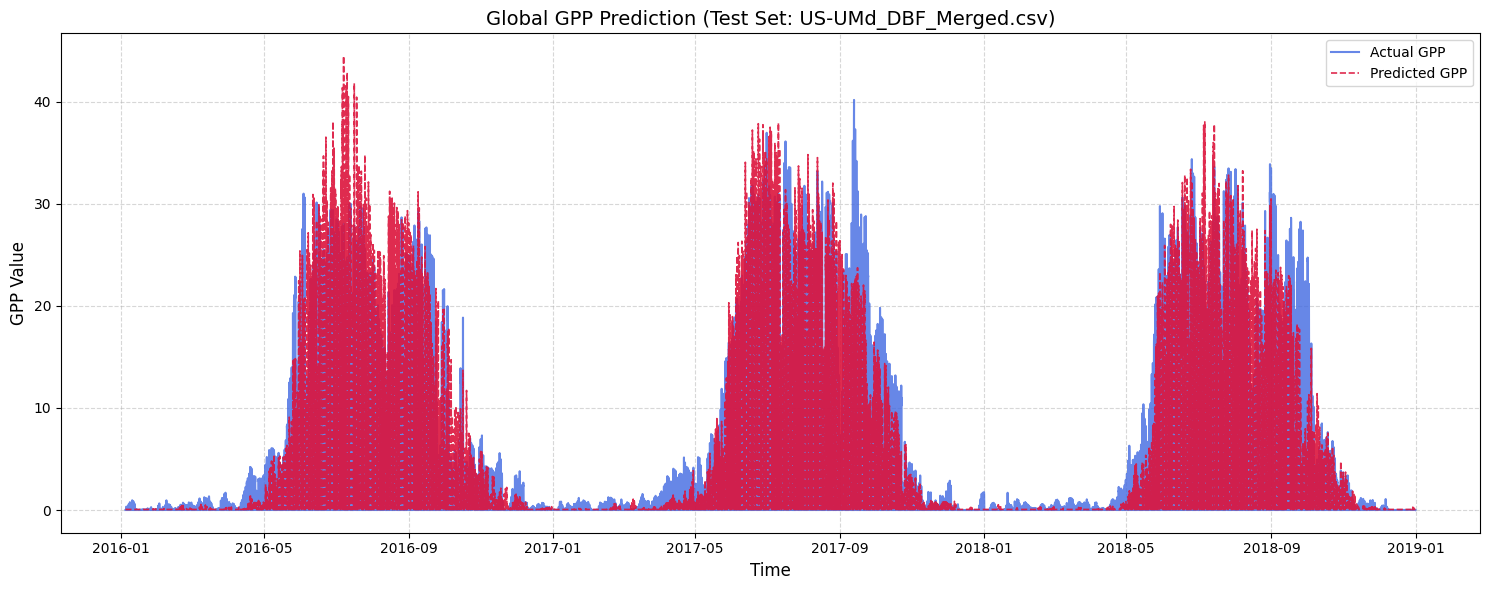

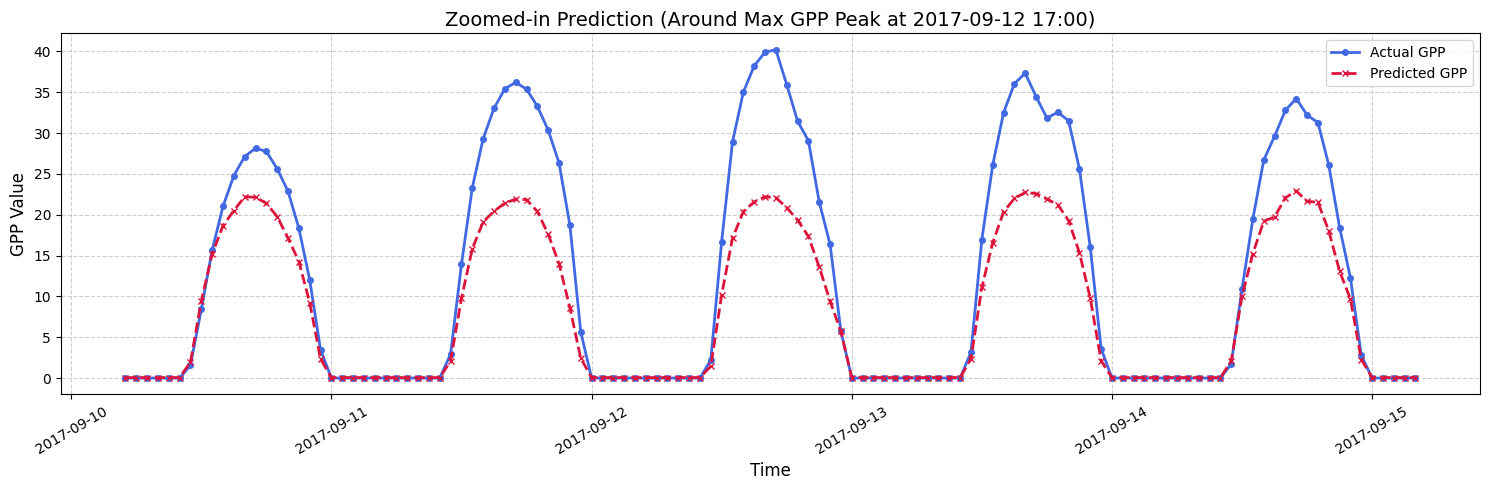

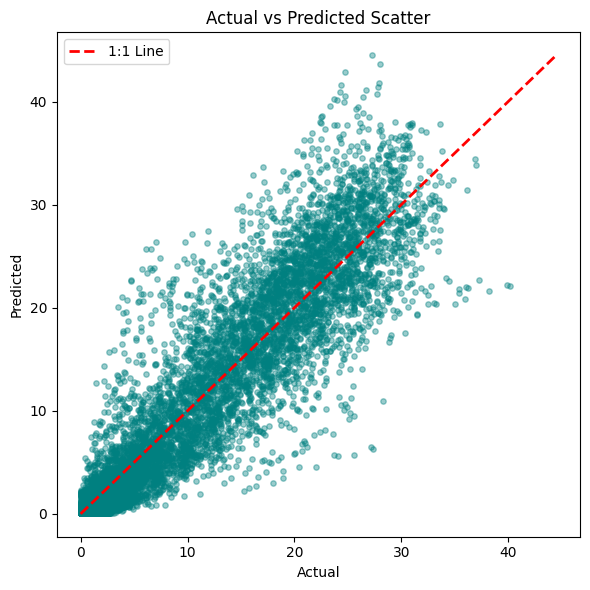

✅ 图表已保存至: ./输出图片/TCN_Transformer双流模型_展平跨站


In [6]:
#改成归一化后低估现象是否会减少？
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import os
import glob
import copy
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import r2_score

# 针对 GPU 的底层加速优化 (可选)
torch.backends.cudnn.benchmark = True

# ==========================================
# 1. 数据集定义 (修改：使用 Z-score 标准化)
# ==========================================
class TimeAwareMultiStationDataset(Dataset):
    def __init__(self, filepaths, seq_len=24, target_col='GPP_DT_VUT_REF', time_col='date',
                 forcing_cols=None, state_cols=None,
                 feat_mean_f=None, feat_std_f=None, feat_mean_s=None, feat_std_s=None):

        self.seq_len = seq_len
        self.samples = []

        self.station_forcing = []
        self.station_state = []
        self.station_time_features = []
        self.station_targets = []
        self.station_dates = []

        for filepath in filepaths:
            data = pd.read_csv(filepath)
            if time_col not in data.columns:
                raise ValueError(f"在文件 {filepath} 中找不到时间列 '{time_col}'")

            data[time_col] = pd.to_datetime(data[time_col])
            data = data.sort_values(by=time_col).reset_index(drop=True)

            # 如果数据长度不足以构成哪怕一个 sequence，则跳过该文件
            if len(data) < seq_len:
                print(f"⚠️ 文件 {filepath} 样本数少于 seq_len，已跳过。")
                continue

            dates = data[time_col]
            self.station_dates.append(dates.values)

            # 提取时间特征 (周期性编码)
            hours = dates.dt.hour.values
            days = dates.dt.dayofyear.values
            time_feats = np.column_stack([
                np.sin(2 * np.pi * hours / 24.0), np.cos(2 * np.pi * hours / 24.0),
                np.sin(2 * np.pi * days / 365.25), np.cos(2 * np.pi * days / 365.25)
            ])

            forcing_data = data[forcing_cols].values
            state_data = data[state_cols].values

            if target_col in data.columns:
                targets = data[target_col].values
            else:
                targets = data.iloc[:, -1].values

            self.station_forcing.append(forcing_data)
            self.station_state.append(state_data)
            self.station_time_features.append(time_feats)
            self.station_targets.append(targets)

        if not self.station_forcing:
            raise ValueError("加载数据失败，可能数据太短或文件列表为空。")

        all_forcing_concat = np.vstack(self.station_forcing)
        all_state_concat = np.vstack(self.station_state)

        # ================== 修改部分：Z-score 标准化 ==================
        # 计算或使用传入的均值和标准差
        self.feat_mean_f = np.mean(all_forcing_concat, axis=0) if feat_mean_f is None else feat_mean_f
        self.feat_std_f = np.std(all_forcing_concat, axis=0) if feat_std_f is None else feat_std_f
        # 防止标准差为 0 导致除零错误
        self.feat_std_f = np.where(self.feat_std_f == 0, 1e-8, self.feat_std_f)

        self.feat_mean_s = np.mean(all_state_concat, axis=0) if feat_mean_s is None else feat_mean_s
        self.feat_std_s = np.std(all_state_concat, axis=0) if feat_std_s is None else feat_std_s
        self.feat_std_s = np.where(self.feat_std_s == 0, 1e-8, self.feat_std_s)

        # 执行标准化 (x - mean) / std 并生成样本索引
        for i in range(len(self.station_forcing)):
            self.station_forcing[i] = (self.station_forcing[i] - self.feat_mean_f) / self.feat_std_f
            self.station_state[i] = (self.station_state[i] - self.feat_mean_s) / self.feat_std_s
        # =============================================================

            num_samples = len(self.station_forcing[i]) - seq_len + 1
            if num_samples > 0:
                for j in range(num_samples):
                    self.samples.append((i, j))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        station_idx, start_idx = self.samples[idx]

        x_forcing = self.station_forcing[station_idx][start_idx : start_idx + self.seq_len]
        x_state = self.station_state[station_idx][start_idx : start_idx + self.seq_len]
        time_x = self.station_time_features[station_idx][start_idx : start_idx + self.seq_len]
        y = self.station_targets[station_idx][start_idx + self.seq_len - 1]
        target_date = self.station_dates[station_idx][start_idx + self.seq_len - 1]

        return (
            torch.tensor(x_forcing, dtype=torch.float32),
            torch.tensor(x_state, dtype=torch.float32),
            torch.tensor(time_x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
            str(target_date)
        )

# ==========================================
# 2. TCN 基础模块定义 (保持原样)
# ==========================================
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super(Chomp1d, self).__init__()
        self.chomp_size = chomp_size
    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()

class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.2):
        super(TemporalBlock, self).__init__()
        self.conv1 = nn.Conv1d(n_inputs, n_outputs, kernel_size, stride=stride, padding=padding, dilation=dilation)
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)
        self.conv2 = nn.Conv1d(n_outputs, n_outputs, kernel_size, stride=stride, padding=padding, dilation=dilation)
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)
        self.net = nn.Sequential(self.conv1, self.chomp1, self.relu1, self.dropout1, self.conv2, self.chomp2, self.relu2, self.dropout2)
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu = nn.ReLU()
    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

class TemporalConvNet(nn.Module):
    def __init__(self, num_inputs, num_channels, kernel_size=3, dropout=0.2):
        super(TemporalConvNet, self).__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = num_inputs if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            layers += [TemporalBlock(in_channels, out_channels, kernel_size, stride=1, dilation=dilation_size,
                                     padding=(kernel_size-1) * dilation_size, dropout=dropout)]
        self.network = nn.Sequential(*layers)
    def forward(self, x):
        return self.network(x)

# ==========================================
# 3. 交叉注意力融合的时空并行模型 (保持原样)
# ==========================================
class TCN_Transformer_CrossAttention(nn.Module):
    def __init__(self, num_forcing_features, num_state_features, seq_len, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1):
        super(TCN_Transformer_CrossAttention, self).__init__()

        self.tcn = TemporalConvNet(num_inputs=num_forcing_features,
                                   num_channels=[d_model] * 6,
                                   kernel_size=3, dropout=dropout)

        self.state_linear = nn.Linear(num_state_features, d_model)
        self.time_projector = nn.Linear(4, d_model)

        encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)

        self.cross_attention = nn.MultiheadAttention(embed_dim=d_model, num_heads=nhead, dropout=dropout, batch_first=True)

        flattened_dim = seq_len * d_model
        self.regressor = nn.Sequential(
            nn.Linear(flattened_dim, flattened_dim // 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(flattened_dim // 4, d_model // 2),
            nn.ReLU(),
            nn.Linear(d_model // 2, 1)
        )

    def forward(self, x_forcing, x_state, time_x):
        x_tcn_in = x_forcing.transpose(1, 2)
        f_tcn = self.tcn(x_tcn_in)
        f_met_memory = f_tcn.transpose(1, 2)

        x_s_emb = self.state_linear(x_state)
        time_emb = self.time_projector(time_x)
        x_state_combined = x_s_emb + time_emb
        f_state_global = self.transformer_encoder(x_state_combined)

        fused_features, _ = self.cross_attention(
            query=f_state_global,
            key=f_met_memory,
            value=f_met_memory
        )

        x_flattened = fused_features.reshape(fused_features.size(0), -1)

        out = self.regressor(x_flattened)
        return out.squeeze(-1)

# ==========================================
# 4. 训练、验证与测试的主流程
# ==========================================
def train_time_aware_model():
    seq_len = 96
    batch_size = 64
    num_epochs = 100
    learning_rate = 0.001
    patience = 10
    TIME_COLUMN_NAME = 'date'

    # 强制检查并使用 GPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if device.type != 'cuda':
        print("⚠️ 警告：当前未检测到可用 GPU，将使用 CPU 进行训练。")
    else:
        print(f"✅ 检测到 GPU: {torch.cuda.get_device_name(0)}，准备起飞！")

    data_folder = r"C:\Users\admin\Desktop\itransformer实验\TSlib数据-DT"
    output_img_folder = r"./输出图片/TCN_Transformer双流模型_展平跨站"
    os.makedirs(output_img_folder, exist_ok=True)

    forcing_cols = ['SW_IN_F', 'SW_IN_POT', 'CO2_F_MDS', 'P_F', 'VPD_F', 'TA_F', 'TS_F_MDS_1', 'SWC_F_MDS_1', 'WS_F']
    state_cols = ['EPIC_Available_Mask', 'Band317nm_Ref', 'Band325nm_Ref', 'Band340nm_Ref',
                  'Band388nm_Ref', 'Band443nm_Ref', 'Band551nm_Ref', 'Band680nm_Ref',
                  'Band688nm_Ref', 'Band764nm_Ref', 'Band780nm_Ref', 'Mean_SZA', 'Mean_VZA', 'Mean_RAA']

    all_files = glob.glob(os.path.join(data_folder, "*.csv"))
    if not all_files:
        print("❌ 错误：未在指定目录找到CSV文件。")
        return

    all_files.sort()
    train_files = all_files[:-2]
    val_files = [all_files[-2]]
    test_files = [all_files[-1]]

    print(f"📁 找到 {len(all_files)} 个文件。")
    print(f"   - 训练集文件数: {len(train_files)}")
    print(f"   - 验证集文件: {os.path.basename(val_files[0])}")
    print(f"   - 测试集文件: {os.path.basename(test_files[0])}")

    train_dataset = TimeAwareMultiStationDataset(
        train_files, seq_len, time_col=TIME_COLUMN_NAME,
        forcing_cols=forcing_cols, state_cols=state_cols
    )
    # 获取训练集的均值和标准差
    f_mean_f, f_std_f = train_dataset.feat_mean_f, train_dataset.feat_std_f
    f_mean_s, f_std_s = train_dataset.feat_mean_s, train_dataset.feat_std_s

    val_dataset = TimeAwareMultiStationDataset(
        val_files, seq_len, time_col=TIME_COLUMN_NAME, forcing_cols=forcing_cols, state_cols=state_cols,
        feat_mean_f=f_mean_f, feat_std_f=f_std_f, feat_mean_s=f_mean_s, feat_std_s=f_std_s
    )
    test_dataset = TimeAwareMultiStationDataset(
        test_files, seq_len, time_col=TIME_COLUMN_NAME, forcing_cols=forcing_cols, state_cols=state_cols,
        feat_mean_f=f_mean_f, feat_std_f=f_std_f, feat_mean_s=f_mean_s, feat_std_s=f_std_s
    )

    # ================== 修改部分：GPU 数据加载优化 ==================
    # pin_memory=True: 锁页内存，加速 CPU 到 GPU 的数据拷贝
    use_pin_memory = True if device.type == 'cuda' else False
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=use_pin_memory)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=use_pin_memory)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=use_pin_memory)
    # ==============================================================

    num_forcing_features = len(forcing_cols)
    num_state_features = len(state_cols)

    model = TCN_Transformer_CrossAttention(
        num_forcing_features=num_forcing_features,
        num_state_features=num_state_features,
        seq_len=seq_len
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_weights = None

    print(f"\n🚀 开始训练 (Forcing->TCN, State->Transformer, Cross-Attn Flattened) (设备: {device})...")
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        train_preds, train_targets = [], []

        for batch_forcing, batch_state, batch_time, batch_y, _ in train_loader:
            # 数据送入 GPU 计算
            batch_forcing = batch_forcing.to(device, non_blocking=True)
            batch_state = batch_state.to(device, non_blocking=True)
            batch_time = batch_time.to(device, non_blocking=True)
            batch_y = batch_y.to(device, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(batch_forcing, batch_state, batch_time)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_preds.extend(outputs.detach().cpu().numpy())
            train_targets.extend(batch_y.cpu().numpy())

        model.eval()
        val_loss = 0
        val_preds, val_targets = [], []
        with torch.no_grad():
            for batch_forcing, batch_state, batch_time, batch_y, _ in val_loader:
                batch_forcing = batch_forcing.to(device, non_blocking=True)
                batch_state = batch_state.to(device, non_blocking=True)
                batch_time = batch_time.to(device, non_blocking=True)
                batch_y = batch_y.to(device, non_blocking=True)

                outputs = model(batch_forcing, batch_state, batch_time)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()
                val_preds.extend(outputs.cpu().numpy())
                val_targets.extend(batch_y.cpu().numpy())

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        train_r2 = r2_score(train_targets, train_preds)
        val_r2 = r2_score(val_targets, val_preds)

        print(f"Epoch [{epoch+1:03d}/{num_epochs}] | Train MSE: {avg_train_loss:.4f}, R²: {train_r2:.4f} | Val MSE: {avg_val_loss:.4f}, R²: {val_r2:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            best_model_weights = copy.deepcopy(model.state_dict())
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"🛑 早停触发。验证集损失连续 {patience} 轮未下降。")
                break

    # ==========================================
    # 5. 独立测试集评估与可视化 (图表逻辑完全对齐)
    # ==========================================
    if best_model_weights is not None:
        model.load_state_dict(best_model_weights)
        model.eval()

        print("\n" + "="*50)
        print(f"🎯 开始测试集评估 (文件: {os.path.basename(test_files[0])})")
        print("="*50)

        all_preds, all_targets, all_times = [], [], []

        with torch.no_grad():
            for batch_forcing, batch_state, batch_time, batch_y, batch_dt in test_loader:
                batch_forcing = batch_forcing.to(device, non_blocking=True)
                batch_state = batch_state.to(device, non_blocking=True)
                batch_time = batch_time.to(device, non_blocking=True)

                outputs = model(batch_forcing, batch_state, batch_time)

                all_preds.extend(outputs.cpu().numpy())
                all_targets.extend(batch_y.numpy())
                all_times.extend(batch_dt)

        all_preds = np.array(all_preds)
        all_targets = np.array(all_targets)
        all_times = pd.to_datetime(all_times)

        mse = np.mean((all_preds - all_targets)**2)
        r2 = r2_score(all_targets, all_preds)

        print(f"Final Test MSE: {mse:.4f}")
        print(f"Final Test R² Score: {r2:.4f}")
        print("="*50)

        test_station_name = os.path.basename(test_files[0]).replace('.csv', '')

        # --- 图表 1: 全局折线图 ---
        plt.figure(figsize=(15, 6))
        plt.plot(all_times, all_targets, label='Actual GPP', color='royalblue', linewidth=1.5, alpha=0.8)
        plt.plot(all_times, all_preds, label='Predicted GPP', color='crimson', linewidth=1.2, linestyle='--', alpha=0.9)
        plt.title(f'Global GPP Prediction (Test Set: {os.path.basename(test_files[0])})', fontsize=14)
        plt.xlabel('Time', fontsize=12)
        plt.ylabel('GPP Value', fontsize=12)
        plt.legend()
        plt.grid(True, which='both', linestyle='--', alpha=0.5)
        plt.tight_layout()
        save_path_1 = os.path.join(output_img_folder, f"{test_station_name}_global_trend.png")
        plt.savefig(save_path_1, dpi=200)
        plt.show()

        # --- 图表 2: 局部峰值放大图 ---
        zoom_days = 5
        steps_per_day = 24
        zoom_steps = zoom_days * steps_per_day
        zoom_steps = min(zoom_steps, len(all_times))

        peak_idx = np.argmax(all_targets)
        start_idx = max(0, peak_idx - zoom_steps // 2)
        end_idx = min(len(all_times), start_idx + zoom_steps)
        start_idx = max(0, end_idx - zoom_steps)

        plt.figure(figsize=(15, 5))
        plt.plot(all_times[start_idx:end_idx], all_targets[start_idx:end_idx],
                 label='Actual GPP', color='royalblue', linewidth=2, marker='o', markersize=4)
        plt.plot(all_times[start_idx:end_idx], all_preds[start_idx:end_idx],
                 label='Predicted GPP', color='crimson', linewidth=2, linestyle='--', marker='x', markersize=4)

        peak_date_str = all_times[peak_idx].strftime('%Y-%m-%d %H:%M')
        plt.title(f'Zoomed-in Prediction (Around Max GPP Peak at {peak_date_str})', fontsize=14)
        plt.xlabel('Time', fontsize=12)
        plt.ylabel('GPP Value', fontsize=12)
        plt.legend()
        plt.grid(True, which='both', linestyle='--', alpha=0.6)
        plt.xticks(rotation=30)
        plt.tight_layout()
        save_path_2 = os.path.join(output_img_folder, f"{test_station_name}_zoomed_trend.png")
        plt.savefig(save_path_2, dpi=200)
        plt.show()

        # --- 图表 3: 散点对比图 ---
        plt.figure(figsize=(6, 6))
        plt.scatter(all_targets, all_preds, alpha=0.4, color='teal', s=15)

        min_val = min(all_targets.min(), all_preds.min())
        max_val = max(all_targets.max(), all_preds.max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 Line')

        plt.title('Actual vs Predicted Scatter')
        plt.xlabel('Actual')
        plt.ylabel('Predicted')
        plt.legend()
        plt.tight_layout()

        save_path_3 = os.path.join(output_img_folder, f"{test_station_name}_scatter.png")
        plt.savefig(save_path_3, dpi=200)
        plt.show()

        print(f"✅ 图表已保存至: {output_img_folder}")

if __name__ == "__main__":
    train_time_aware_model()

In [13]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import os
import glob
import copy
import matplotlib.pyplot as plt
import shap
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import r2_score

# ==========================================
# 1. 数据集定义 (融入地类与经纬度提取)
# ==========================================
class TimeAwareMultiStationDataset(Dataset):
    def __init__(self, filepaths, seq_len=24, target_col='GPP_DT_VUT_REF', time_col='date',
                 forcing_cols=None, state_cols=None,
                 static_cols=['Lat', 'Long'], lc_col='Veg_ID',
                 feat_min_f=None, feat_max_f=None, feat_min_s=None, feat_max_s=None,
                 static_min=None, static_max=None, split_type='train'):

        self.seq_len = seq_len
        self.samples = []

        self.station_forcing = []
        self.station_state = []
        self.station_time_features = []
        self.station_targets = []
        self.station_dates = []

        self.station_static = []
        self.station_lc = []

        for filepath in filepaths:
            data = pd.read_csv(filepath)
            if time_col not in data.columns:
                raise ValueError(f"在文件 {filepath} 中找不到时间列 '{time_col}'")

            data[time_col] = pd.to_datetime(data[time_col])
            data = data.sort_values(by=time_col).reset_index(drop=True)

            n_samples = len(data)
            train_end = int(n_samples * 0.4)
            val_end = int(n_samples * 0.7)

            if split_type == 'train':
                data = data.iloc[:train_end]
            elif split_type == 'val':
                start_idx = max(0, train_end - self.seq_len + 1)
                data = data.iloc[start_idx:val_end]
            elif split_type == 'test':
                start_idx = max(0, val_end - self.seq_len + 1)
                data = data.iloc[start_idx:]

            if len(data) < seq_len:
                continue

            dates = data[time_col]
            self.station_dates.append(dates.values)

            hours = dates.dt.hour.values
            days = dates.dt.dayofyear.values
            time_feats = np.column_stack([
                np.sin(2 * np.pi * hours / 24.0), np.cos(2 * np.pi * hours / 24.0),
                np.sin(2 * np.pi * days / 365.25), np.cos(2 * np.pi * days / 365.25)
            ])

            forcing_data = data[forcing_cols].values
            state_data = data[state_cols].values

            static_data = data[static_cols].values
            lc_data = data[lc_col].values.astype(np.int64)

            if target_col in data.columns:
                targets = data[target_col].values
            else:
                targets = data.iloc[:, -1].values

            self.station_forcing.append(forcing_data)
            self.station_state.append(state_data)
            self.station_time_features.append(time_feats)
            self.station_targets.append(targets)
            self.station_static.append(static_data)
            self.station_lc.append(lc_data)

        if not self.station_forcing:
            raise ValueError(f"加载 {split_type} 数据失败，可能数据太短或文件列表为空。")

        all_forcing_concat = np.vstack(self.station_forcing)
        all_state_concat = np.vstack(self.station_state)
        all_static_concat = np.vstack(self.station_static)

        self.feat_min_f = np.min(all_forcing_concat, axis=0) if feat_min_f is None else feat_min_f
        self.feat_max_f = np.max(all_forcing_concat, axis=0) if feat_max_f is None else feat_max_f
        self.feat_min_s = np.min(all_state_concat, axis=0) if feat_min_s is None else feat_min_s
        self.feat_max_s = np.max(all_state_concat, axis=0) if feat_max_s is None else feat_max_s

        self.static_min = np.min(all_static_concat, axis=0) if static_min is None else static_min
        self.static_max = np.max(all_static_concat, axis=0) if static_max is None else static_max

        for i in range(len(self.station_forcing)):
            self.station_forcing[i] = (self.station_forcing[i] - self.feat_min_f) / (self.feat_max_f - self.feat_min_f + 1e-8)
            self.station_state[i] = (self.station_state[i] - self.feat_min_s) / (self.feat_max_s - self.feat_min_s + 1e-8)
            self.station_static[i] = (self.station_static[i] - self.static_min) / (self.static_max - self.static_min + 1e-8)

            num_samples = len(self.station_forcing[i]) - seq_len + 1
            if num_samples > 0:
                for j in range(num_samples):
                    self.samples.append((i, j))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        station_idx, start_idx = self.samples[idx]

        x_forcing = self.station_forcing[station_idx][start_idx : start_idx + self.seq_len]
        x_state = self.station_state[station_idx][start_idx : start_idx + self.seq_len]
        time_x = self.station_time_features[station_idx][start_idx : start_idx + self.seq_len]
        y = self.station_targets[station_idx][start_idx + self.seq_len - 1]
        target_date = self.station_dates[station_idx][start_idx + self.seq_len - 1]

        x_static = self.station_static[station_idx][start_idx : start_idx + self.seq_len]
        x_lc = self.station_lc[station_idx][start_idx : start_idx + self.seq_len]

        return (
            torch.tensor(x_forcing, dtype=torch.float32),
            torch.tensor(x_state, dtype=torch.float32),
            torch.tensor(time_x, dtype=torch.float32),
            torch.tensor(x_static, dtype=torch.float32),
            torch.tensor(x_lc, dtype=torch.long),
            torch.tensor(y, dtype=torch.float32),
            str(target_date)
        )

# ==========================================
# 2. TCN 基础模块定义
# ==========================================
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super(Chomp1d, self).__init__()
        self.chomp_size = chomp_size
    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()

class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.2):
        super(TemporalBlock, self).__init__()
        self.conv1 = nn.Conv1d(n_inputs, n_outputs, kernel_size, stride=stride, padding=padding, dilation=dilation)
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)
        self.conv2 = nn.Conv1d(n_outputs, n_outputs, kernel_size, stride=stride, padding=padding, dilation=dilation)
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)
        self.net = nn.Sequential(self.conv1, self.chomp1, self.relu1, self.dropout1, self.conv2, self.chomp2, self.relu2, self.dropout2)
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu = nn.ReLU()
    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

class TemporalConvNet(nn.Module):
    def __init__(self, num_inputs, num_channels, kernel_size=3, dropout=0.2):
        super(TemporalConvNet, self).__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = num_inputs if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            layers += [TemporalBlock(in_channels, out_channels, kernel_size, stride=1, dilation=dilation_size,
                                     padding=(kernel_size-1) * dilation_size, dropout=dropout)]
        self.network = nn.Sequential(*layers)
    def forward(self, x):
        return self.network(x)

# ==========================================
# 3. 交叉注意力融合模型
# ==========================================
class TCN_Transformer_CrossAttention(nn.Module):
    def __init__(self, num_forcing_features, num_state_features, seq_len,
                 num_static=2, num_lc_classes=10, lc_embed_dim=8,
                 d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1):
        super(TCN_Transformer_CrossAttention, self).__init__()

        self.tcn = TemporalConvNet(num_inputs=num_forcing_features,
                                   num_channels=[d_model] * 6,
                                   kernel_size=3, dropout=dropout)

        self.lc_embedding = nn.Embedding(num_embeddings=num_lc_classes, embedding_dim=lc_embed_dim)

        combined_state_dim = num_state_features + num_static + lc_embed_dim
        self.state_linear = nn.Linear(combined_state_dim, d_model)

        self.time_projector = nn.Linear(4, d_model)

        encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)

        self.cross_attention = nn.MultiheadAttention(embed_dim=d_model, num_heads=nhead, dropout=dropout, batch_first=True)

        self.regressor = nn.Sequential(
            nn.Linear(d_model, d_model // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d_model // 2, d_model // 4), nn.ReLU(),
            nn.Linear(d_model // 4, 1)
        )

    def forward(self, x_forcing, x_state, time_x, x_static, x_lc):
        x_tcn_in = x_forcing.transpose(1, 2)
        f_tcn = self.tcn(x_tcn_in)
        f_met_memory = f_tcn.transpose(1, 2)

        lc_emb = self.lc_embedding(x_lc)
        combined_state = torch.cat([x_state, x_static, lc_emb], dim=-1)

        x_s_emb = self.state_linear(combined_state)
        time_emb = self.time_projector(time_x)
        x_state_combined = x_s_emb + time_emb
        f_state_global = self.transformer_encoder(x_state_combined)

        fused_features, _ = self.cross_attention(
            query=f_state_global,
            key=f_met_memory,
            value=f_met_memory
        )

        last_step_features = fused_features[:, -1, :]
        out = self.regressor(last_step_features)
        return out.squeeze(-1)

# ==========================================
# 4. SHAP 分析核心代码 (彻底修复重叠陷阱与正负抵消)
# ==========================================
def perform_shap_analysis(model, dataloader, device, output_img_folder, forcing_cols, state_cols):
    print("\n🔍 开始执行 SHAP 变量重要性分析 (启用随机采样与时序展平)...")
    model.eval()

    # 【核心修复 1：打乱数据】专门构建一个 shuffle=True 的加载器
    # 确保背景样本和测试样本来自不同的季节和站点，避免滑动窗口导致的特征差值为 0
    shap_loader = DataLoader(dataloader.dataset, batch_size=120, shuffle=True)
    batch = next(iter(shap_loader))

    batch_forcing, batch_state, batch_time = batch[0].to(device), batch[1].to(device), batch[2].to(device)
    batch_static, batch_lc = batch[3].to(device), batch[4].to(device)

    bg_size, test_size = 50, 50
    if batch_forcing.size(0) < (bg_size + test_size):
        print("⚠️ Batch size 太小，跳过 SHAP 分析。")
        return

    bg_f, bg_s = batch_forcing[:bg_size], batch_state[:bg_size]
    test_f, test_s = batch_forcing[bg_size:bg_size+test_size], batch_state[bg_size:bg_size+test_size]

    # 包装类：固定静态和上下文变量，动态适配 SHAP 内部生成的 Batch Size
    class SHAPWrapper(nn.Module):
        def __init__(self, base_model, t_ref, st_ref, lc_ref):
            super().__init__()
            self.base_model = base_model
            # 仅截取第一个样本作为锚点，避免维度越界
            self.t_ref = t_ref[:1]
            self.st_ref = st_ref[:1]
            self.lc_ref = lc_ref[:1]

        def forward(self, x_f, x_s):
            b_size = x_f.size(0)
            # 使用 expand 动态复制上下文以匹配 SHAP 的插值矩阵
            t_x = self.t_ref.expand(b_size, -1, -1)
            x_st = self.st_ref.expand(b_size, -1, -1)
            x_l = self.lc_ref.expand(b_size, -1)
            out = self.base_model(x_f, x_s, t_x, x_st, x_l)
            return out.unsqueeze(-1)

    wrapper_model = SHAPWrapper(model, batch_time, batch_static, batch_lc).to(device)
    wrapper_model.eval()

    explainer = shap.GradientExplainer(wrapper_model, [bg_f, bg_s])
    shap_values = explainer.shap_values([test_f, test_s])

    # 剥离可能存在的多余 list 嵌套
    if isinstance(shap_values, list) and len(shap_values) == 1 and isinstance(shap_values[0], list):
        shap_values = shap_values[0]

    shap_forcing = np.array(shap_values[0])  # 形状: (50, 96, 9)
    shap_state = np.array(shap_values[1])    # 形状: (50, 96, 14)

    # 【核心修复 2：展平时间维度】
    # 将 (Batch, Seq, Feat) 展平为 (Batch * Seq, Feat) -> 即 50 * 96 = 4800 个独立观测点
    # 这样不仅避免了时间上的正负抵消，还能绘制出信息量极高的 Beeswarm 蜂群分布图
    shap_forcing_2d = shap_forcing.reshape(-1, len(forcing_cols))
    shap_state_2d = shap_state.reshape(-1, len(state_cols))

    test_f_2d = test_f.cpu().numpy().reshape(-1, len(forcing_cols))
    test_s_2d = test_s.cpu().numpy().reshape(-1, len(state_cols))

    shap_combined = np.concatenate([shap_forcing_2d, shap_state_2d], axis=1)
    features_combined = np.concatenate([test_f_2d, test_s_2d], axis=1)
    feature_names = forcing_cols + state_cols

    plt.figure(figsize=(12, 10))
    shap.summary_plot(shap_combined, features_combined, feature_names=feature_names, show=False)
    plt.title("SHAP Summary: Global Feature Impact on GPP (Time-Flattened)", fontname='Arial', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(output_img_folder, "SHAP_Summary_Plot.png"), dpi=300)
    plt.close()

    plt.figure(figsize=(12, 10))
    shap.summary_plot(shap_combined, features_combined, feature_names=feature_names, plot_type="bar", show=False)
    plt.title("SHAP Global Feature Importance (Magnitude)", fontname='Arial', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(output_img_folder, "SHAP_Bar_Plot.png"), dpi=300)
    plt.close()

    print(f"✅ SHAP 彻底修复！生成了 {shap_combined.shape[0]} 个时序数据点的蜂群图，已保存至: {output_img_folder}")

# ==========================================
# 5. 训练、验证与测试的主流程 (增强断点记忆功能)
# ==========================================
def train_time_aware_model():
    seq_len = 96
    batch_size = 64
    num_epochs = 100
    learning_rate = 0.001
    patience = 10
    TIME_COLUMN_NAME = 'date'
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    data_folder = r"C:\Users\Admin\Desktop\实验三\全波段全变量DT"
    output_img_folder = os.path.join(data_folder, "Results_TCN_Transformer433")
    os.makedirs(output_img_folder, exist_ok=True)

    forcing_cols = ['SW_IN_F', 'SW_IN_POT', 'CO2_F_MDS', 'P_F', 'VPD_F', 'TA_F', 'TS_F_MDS_1', 'SWC_F_MDS_1', 'WS_F']
    state_cols = ['EPIC_Available_Mask', 'Band317nm_Ref', 'Band325nm_Ref', 'Band340nm_Ref',
                  'Band388nm_Ref', 'Band443nm_Ref', 'Band551nm_Ref', 'Band680nm_Ref',
                  'Band688nm_Ref', 'Band764nm_Ref', 'Band780nm_Ref', 'Mean_SZA', 'Mean_VZA', 'Mean_RAA']

    static_cols = ['Lat', 'Long']
    lc_col = 'Veg_ID'

    all_files = glob.glob(os.path.join(data_folder, "*.csv"))
    if not all_files:
        print("❌ 错误：未在指定目录找到CSV文件。")
        return

    print(f"📁 共找到 {len(all_files)} 个站点文件。")
    print(f"📁 结果图表与模型将保存回源目录: {output_img_folder}")

    train_dataset = TimeAwareMultiStationDataset(
        all_files, seq_len, time_col=TIME_COLUMN_NAME,
        forcing_cols=forcing_cols, state_cols=state_cols,
        static_cols=static_cols, lc_col=lc_col, split_type='train'
    )

    f_min_f, f_max_f = train_dataset.feat_min_f, train_dataset.feat_max_f
    f_min_s, f_max_s = train_dataset.feat_min_s, train_dataset.feat_max_s
    s_min, s_max = train_dataset.static_min, train_dataset.static_max

    val_dataset = TimeAwareMultiStationDataset(
        all_files, seq_len, time_col=TIME_COLUMN_NAME,
        forcing_cols=forcing_cols, state_cols=state_cols,
        static_cols=static_cols, lc_col=lc_col,
        feat_min_f=f_min_f, feat_max_f=f_max_f, feat_min_s=f_min_s, feat_max_s=f_max_s,
        static_min=s_min, static_max=s_max, split_type='val'
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    num_forcing_features = len(forcing_cols)
    num_state_features = len(state_cols)

    model = TCN_Transformer_CrossAttention(
        num_forcing_features=num_forcing_features,
        num_state_features=num_state_features,
        seq_len=seq_len,
        num_static=len(static_cols),
        num_lc_classes=10,
        lc_embed_dim=8
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    checkpoint_latest_path = os.path.join(output_img_folder, "checkpoint_latest.pth")
    checkpoint_best_path = os.path.join(output_img_folder, "checkpoint_best.pth")

    start_epoch = 0
    best_val_loss = float('inf')
    epochs_no_improve = 0

    # ---------------------------------------------------------
    # 【强化功能：自动检测并加载本地历史参数（断点续训）】
    # ---------------------------------------------------------
    if os.path.exists(checkpoint_latest_path):
        print(f"\n🔄 检测到本地存在中断的训练记录 ({checkpoint_latest_path})，正在无缝恢复...")
        checkpoint = torch.load(checkpoint_latest_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_loss = checkpoint['best_val_loss']
        epochs_no_improve = checkpoint['epochs_no_improve']
        print(f"✅ 成功从第 {start_epoch} 个 Epoch 恢复训练！历史最佳验证集 MSE 为: {best_val_loss:.4f}")
    else:
        print(f"\n🆕 未检测到历史进度，将从头开始全新的训练。")

    if start_epoch < num_epochs and epochs_no_improve < patience:
        print(f"🚀 开始训练...\n" + "-"*40)
        for epoch in range(start_epoch, num_epochs):
            model.train()
            train_loss = 0

            for batch_forcing, batch_state, batch_time, batch_static, batch_lc, batch_y, _ in train_loader:
                batch_forcing, batch_state, batch_time = batch_forcing.to(device), batch_state.to(device), batch_time.to(device)
                batch_static, batch_lc, batch_y = batch_static.to(device), batch_lc.to(device), batch_y.to(device)

                optimizer.zero_grad()
                outputs = model(batch_forcing, batch_state, batch_time, batch_static, batch_lc)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()

                train_loss += loss.item()

            model.eval()
            val_loss = 0
            with torch.no_grad():
                for batch_forcing, batch_state, batch_time, batch_static, batch_lc, batch_y, _ in val_loader:
                    batch_forcing, batch_state, batch_time = batch_forcing.to(device), batch_state.to(device), batch_time.to(device)
                    batch_static, batch_lc, batch_y = batch_static.to(device), batch_lc.to(device), batch_y.to(device)

                    outputs = model(batch_forcing, batch_state, batch_time, batch_static, batch_lc)
                    loss = criterion(outputs, batch_y)
                    val_loss += loss.item()

            avg_train_loss = train_loss / len(train_loader)
            avg_val_loss = val_loss / len(val_loader)
            print(f"Epoch [{epoch+1:03d}/{num_epochs}] | Train MSE: {avg_train_loss:.4f} | Val MSE: {avg_val_loss:.4f}")

            # ---------------------------------------------------------
            # 【强化功能：实时保存最佳模型参数与最新状态】
            # ---------------------------------------------------------
            if avg_val_loss < best_val_loss:
                print(f"   🌟 发现新的最佳模型！验证集 MSE 从 {best_val_loss:.4f} 降至 {avg_val_loss:.4f}。")
                print(f"   💾 最佳参数已硬拷贝至本地: {checkpoint_best_path}")
                best_val_loss = avg_val_loss
                epochs_no_improve = 0
                torch.save(model.state_dict(), checkpoint_best_path)
            else:
                epochs_no_improve += 1
                print(f"   ⏳ 验证集 MSE 未改善 (早停计数: {epochs_no_improve}/{patience})")

            # 不管是不是最佳，每一轮结束后都保存最新的状态（包含优化器进度，方便随时断点重启）
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_loss': best_val_loss,
                'epochs_no_improve': epochs_no_improve
            }, checkpoint_latest_path)
            # print(f"   🔄 当前进度已自动备份至 latest 权重文件。") # 觉得提示太多可以注掉这行

            if epochs_no_improve >= patience:
                print(f"\n🛑 触发早停机制，在连续 {patience} 个 Epoch 中验证集表现未提升，训练提前结束。")
                break
            print("-" * 40)

    # ==========================================
    # 6. 分站点独立测试评估
    # ==========================================
    if os.path.exists(checkpoint_best_path):
        print(f"\n🎯 训练结束，正在加载全局表现最好的模型参数进行测试集评估...")
        model.load_state_dict(torch.load(checkpoint_best_path, map_location=device))

    model.eval()

    global_all_preds, global_all_targets = [], []
    for test_file in all_files:
        station_name = os.path.basename(test_file).replace('.csv', '')
        single_test_dataset = TimeAwareMultiStationDataset(
            [test_file], seq_len, time_col=TIME_COLUMN_NAME,
            forcing_cols=forcing_cols, state_cols=state_cols,
            static_cols=static_cols, lc_col=lc_col,
            feat_min_f=f_min_f, feat_max_f=f_max_f, feat_min_s=f_min_s, feat_max_s=f_max_s,
            static_min=s_min, static_max=s_max, split_type='test'
        )

        if len(single_test_dataset) == 0: continue

        single_test_loader = DataLoader(single_test_dataset, batch_size=batch_size, shuffle=False)
        all_preds, all_targets, all_times = [], [], []

        with torch.no_grad():
            for batch_forcing, batch_state, batch_time, batch_static, batch_lc, batch_y, batch_dt in single_test_loader:
                batch_forcing, batch_state, batch_time = batch_forcing.to(device), batch_state.to(device), batch_time.to(device)
                batch_static, batch_lc = batch_static.to(device), batch_lc.to(device)

                outputs = model(batch_forcing, batch_state, batch_time, batch_static, batch_lc)
                all_preds.extend(outputs.cpu().numpy())
                all_targets.extend(batch_y.numpy())
                all_times.extend(batch_dt)

        all_preds, all_targets = np.array(all_preds), np.array(all_targets)
        all_times = pd.to_datetime(all_times)

        global_all_preds.extend(all_preds)
        global_all_targets.extend(all_targets)

        print(f"📢 站点: {station_name} | 测试集 R²: {r2_score(all_targets, all_preds):.4f}")

        # 图表 1: 滑动平均趋势图
        window_size = 12
        all_targets_smooth = pd.Series(all_targets).rolling(window=window_size, min_periods=1).mean().values
        all_preds_smooth = pd.Series(all_preds).rolling(window=window_size, min_periods=1).mean().values

        plt.figure(figsize=(15, 6))
        plt.plot(all_times, all_targets, color='royalblue', linewidth=0.5, alpha=0.2, label='Actual (Raw)')
        plt.plot(all_times, all_preds, color='crimson', linewidth=0.5, alpha=0.2, label='Predicted (Raw)')
        plt.plot(all_times, all_targets_smooth, label=f'Actual GPP (MA-{window_size})', color='royalblue', linewidth=1.5, alpha=0.9)
        plt.plot(all_times, all_preds_smooth, label=f'Predicted GPP (MA-{window_size})', color='crimson', linewidth=1.5, linestyle='--', alpha=0.9)

        plt.title(f'[{station_name}] Test Set GPP Prediction (Moving Average Window={window_size})', fontsize=14, fontname='Arial')
        plt.xlabel('Time', fontsize=12, fontname='Arial')
        plt.ylabel('GPP Value', fontsize=12, fontname='Arial')
        plt.legend(prop={'family': 'Arial'})

        ax = plt.gca()
        ax.tick_params(direction='in')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.grid(True, which='both', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.savefig(os.path.join(output_img_folder, f"{station_name}_trend_ma.png"), dpi=300)
        plt.close()

        # 图表 2: 局部放大图 (30天)
        zoom_days = 30
        steps_per_day = 24
        zoom_steps = zoom_days * steps_per_day
        zoom_steps = min(zoom_steps, len(all_times))

        if zoom_steps > 0:
            peak_idx = np.argmax(all_targets_smooth)
            start_idx = max(0, peak_idx - zoom_steps // 2)
            end_idx = min(len(all_times), start_idx + zoom_steps)

            if end_idx - start_idx < zoom_steps:
                start_idx = max(0, end_idx - zoom_steps)

            plt.figure(figsize=(15, 5))
            plt.plot(all_times[start_idx:end_idx], all_targets_smooth[start_idx:end_idx],
                     label='Actual GPP', color='royalblue', linewidth=2)
            plt.plot(all_times[start_idx:end_idx], all_preds_smooth[start_idx:end_idx],
                     label='Predicted GPP', color='crimson', linewidth=2, linestyle='--')

            peak_date_str = all_times[peak_idx].strftime('%Y-%m-%d %H:%M')
            plt.title(f'[{station_name}] 30-Day Zoomed Prediction (Peak around {peak_date_str})', fontsize=14, fontname='Arial')
            plt.xlabel('Time', fontsize=12, fontname='Arial')
            plt.ylabel('GPP Value', fontsize=12, fontname='Arial')
            plt.legend(prop={'family': 'Arial'})

            ax = plt.gca()
            ax.tick_params(direction='in')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            plt.grid(True, which='both', linestyle='--', alpha=0.6)
            plt.xticks(rotation=30)
            plt.tight_layout()
            plt.savefig(os.path.join(output_img_folder, f"{station_name}_zoom_30days.png"), dpi=300)
            plt.close()

        # 图表 3: 散点图
        plt.figure(figsize=(6, 6))
        plt.scatter(all_targets, all_preds, alpha=0.6, color='teal', s=15, edgecolors='k', linewidth=0.2)

        min_val = min(all_targets.min(), all_preds.min())
        max_val = max(all_targets.max(), all_preds.max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 Line')

        plt.title(f'[{station_name}] Actual vs Predicted Scatter', fontname='Arial')
        plt.xlabel('Actual GPP', fontname='Arial')
        plt.ylabel('Predicted GPP', fontname='Arial')
        plt.legend(prop={'family': 'Arial'})

        ax = plt.gca()
        ax.tick_params(direction='in')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.tight_layout()
        plt.savefig(os.path.join(output_img_folder, f"{station_name}_scatter.png"), dpi=300)
        plt.close()

    if len(global_all_targets) > 0:
        global_all_preds = np.array(global_all_preds)
        global_all_targets = np.array(global_all_targets)

        global_mse = np.mean((global_all_preds - global_all_targets)**2)
        global_r2 = r2_score(global_all_targets, global_all_preds)

        print("\n" + "="*50)
        print("🌎 所有站点测试集全局评估结果")
        print("="*50)
        print(f"总测试样本数: {len(global_all_targets)}")
        print(f"Global Test MSE: {global_mse:.4f}")
        print(f"Global Test R² Score: {global_r2:.4f}")
        print("="*50)

        # ------------------------------------------
        # 7. 触发 SHAP 分析
        # ------------------------------------------
        try:
            perform_shap_analysis(
                model=model,
                dataloader=val_loader,
                device=device,
                output_img_folder=output_img_folder,
                forcing_cols=forcing_cols,
                state_cols=state_cols
            )
        except Exception as e:
            print(f"⚠️ SHAP 分析过程中出现异常: {e}")

if __name__ == "__main__":
    train_time_aware_model()

📁 共找到 69 个站点文件。
📁 结果图表与模型将保存回源目录: C:\Users\Admin\Desktop\实验三\全波段全变量DT\Results_TCN_Transformer433

🔄 检测到本地存在中断的训练记录 (C:\Users\Admin\Desktop\实验三\全波段全变量DT\Results_TCN_Transformer433\checkpoint_latest.pth)，正在无缝恢复...
✅ 成功从第 31 个 Epoch 恢复训练！历史最佳验证集 MSE 为: 2.1475

🎯 训练结束，正在加载全局表现最好的模型参数进行测试集评估...
📢 站点: CA-Cbo_DBF_Merged | 测试集 R²: 0.8198
📢 站点: CA-Mer_WET_Merged | 测试集 R²: 0.6067
📢 站点: CA-TP1_ENF_Merged | 测试集 R²: 0.7701
📢 站点: CA-TP3_ENF_Merged | 测试集 R²: 0.8114
📢 站点: CL-ACF_ENF_Merged | 测试集 R²: 0.8114
📢 站点: CL-SDP_WET_Merged | 测试集 R²: 0.8622
📢 站点: CR-Fsc_CRO_Merged | 测试集 R²: 0.5594
📢 站点: US-A37_CVM_Merged | 测试集 R²: -1.3095
📢 站点: US-A39_CRO_Merged | 测试集 R²: 0.1134
📢 站点: US-Bar_DBF_Merged | 测试集 R²: 0.8210
📢 站点: US-BZS_ENF_Merged | 测试集 R²: 0.8774
📢 站点: US-CdM_WSA_Merged | 测试集 R²: 0.1595
📢 站点: US-CRK_ENF_Merged | 测试集 R²: 0.0975
📢 站点: US-HB3_ENF_Merged | 测试集 R²: 0.9353
📢 站点: US-Jo2_OSH_Merged | 测试集 R²: 0.0793
📢 站点: US-KFS_GRA_Merged | 测试集 R²: 0.7585
📢 站点: US-Kon_GRA_Merged | 测试集 R²: 0.5011
📢 站点: US-Me

C:\Users\admin\AppData\Local\Temp\ipykernel_7464\1952812352.py:304: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_combined, features_combined, feature_names=feature_names, show=False)
C:\Users\admin\AppData\Local\Temp\ipykernel_7464\1952812352.py:311: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_combined, features_combined, feature_names=feature_names, plot_type="bar", show=False)


✅ SHAP 彻底修复！生成了 4800 个时序数据点的蜂群图，已保存至: C:\Users\Admin\Desktop\实验三\全波段全变量DT\Results_TCN_Transformer433


In [4]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import shap
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import r2_score

# ==========================================
# 1. 数据集定义 (缺失值自动填补 + 断层检测)
# ==========================================
class TimeAwareMultiStationDataset(Dataset):
    def __init__(self, filepaths, seq_len=24, target_col='GPP_DT_VUT_REF', time_col='date',
                 forcing_cols=None, state_cols=None,
                 static_cols=['Lat', 'Long'], lc_col='Veg_ID',
                 feat_min_f=None, feat_max_f=None, feat_min_s=None, feat_max_s=None,
                 static_min=None, static_max=None, split_type='train'):

        self.seq_len = seq_len
        self.samples = []

        self.station_forcing = []
        self.station_state = []
        self.station_time_features = []
        self.station_targets = []
        self.station_dates = []

        self.station_static = []
        self.station_lc = []

        for filepath in filepaths:
            data = pd.read_csv(filepath)
            if time_col not in data.columns:
                print(f"⚠️ 在文件 {filepath} 中找不到时间列 '{time_col}'，跳过。")
                continue

            # 异常值清洗与插值填补 NaN
            data = data.replace([-9999, -9999.0, -999], np.nan)
            cols_to_clean = forcing_cols + state_cols + [target_col]
            cols_exist = [c for c in cols_to_clean if c in data.columns]

            data[cols_exist] = data[cols_exist].interpolate(method='linear', limit_direction='both')
            data = data.dropna(subset=cols_exist).reset_index(drop=True)

            data[time_col] = pd.to_datetime(data[time_col])
            data = data.sort_values(by=time_col).reset_index(drop=True)

            if len(data) < seq_len:
                continue

            dates = data[time_col]
            self.station_dates.append(dates.values)

            hours = dates.dt.hour.values
            days = dates.dt.dayofyear.values
            time_feats = np.column_stack([
                np.sin(2 * np.pi * hours / 24.0), np.cos(2 * np.pi * hours / 24.0),
                np.sin(2 * np.pi * days / 365.25), np.cos(2 * np.pi * days / 365.25)
            ])

            forcing_data = data[forcing_cols].values
            state_data = data[state_cols].values
            static_data = data[static_cols].values
            lc_data = data[lc_col].values.astype(np.int64)

            if target_col in data.columns:
                targets = data[target_col].values
            else:
                targets = data.iloc[:, -1].values

            self.station_forcing.append(forcing_data)
            self.station_state.append(state_data)
            self.station_time_features.append(time_feats)
            self.station_targets.append(targets)
            self.station_static.append(static_data)
            self.station_lc.append(lc_data)

        if not self.station_forcing:
            raise ValueError(f"加载 {split_type} 数据失败，可能所有数据均被清洗掉或长度不足。")

        all_forcing_concat = np.vstack(self.station_forcing)
        all_state_concat = np.vstack(self.station_state)
        all_static_concat = np.vstack(self.station_static)

        self.feat_min_f = np.min(all_forcing_concat, axis=0) if feat_min_f is None else feat_min_f
        self.feat_max_f = np.max(all_forcing_concat, axis=0) if feat_max_f is None else feat_max_f
        self.feat_min_s = np.min(all_state_concat, axis=0) if feat_min_s is None else feat_min_s
        self.feat_max_s = np.max(all_state_concat, axis=0) if feat_max_s is None else feat_max_s

        self.static_min = np.min(all_static_concat, axis=0) if static_min is None else static_min
        self.static_max = np.max(all_static_concat, axis=0) if static_max is None else static_max

        # 归一化与样本切分 (包含时间连续性断层检测)
        for i in range(len(self.station_forcing)):
            self.station_forcing[i] = (self.station_forcing[i] - self.feat_min_f) / (self.feat_max_f - self.feat_min_f + 1e-8)
            self.station_state[i] = (self.station_state[i] - self.feat_min_s) / (self.feat_max_s - self.feat_min_s + 1e-8)
            self.station_static[i] = (self.station_static[i] - self.static_min) / (self.static_max - self.static_min + 1e-8)

            dates_array = self.station_dates[i]
            if len(dates_array) > 1:
                diffs = pd.Series(dates_array).diff()
                mode_step = diffs.mode()[0]
                expected_duration = mode_step * (self.seq_len - 1)

                num_samples = len(self.station_forcing[i]) - self.seq_len + 1
                if num_samples > 0:
                    for j in range(num_samples):
                        actual_duration = pd.Timedelta(dates_array[j + self.seq_len - 1] - dates_array[j])
                        if actual_duration == expected_duration:
                            self.samples.append((i, j))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        station_idx, start_idx = self.samples[idx]

        x_forcing = self.station_forcing[station_idx][start_idx : start_idx + self.seq_len]
        x_state = self.station_state[station_idx][start_idx : start_idx + self.seq_len]
        time_x = self.station_time_features[station_idx][start_idx : start_idx + self.seq_len]
        y = self.station_targets[station_idx][start_idx + self.seq_len - 1]
        target_date = self.station_dates[station_idx][start_idx + self.seq_len - 1]

        x_static = self.station_static[station_idx][start_idx : start_idx + self.seq_len]
        x_lc = self.station_lc[station_idx][start_idx : start_idx + self.seq_len]

        return (
            torch.tensor(x_forcing, dtype=torch.float32),
            torch.tensor(x_state, dtype=torch.float32),
            torch.tensor(time_x, dtype=torch.float32),
            torch.tensor(x_static, dtype=torch.float32),
            torch.tensor(x_lc, dtype=torch.long),
            torch.tensor(y, dtype=torch.float32),
            str(target_date)
        )

# ==========================================
# 2. TCN 基础模块定义
# ==========================================
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super(Chomp1d, self).__init__()
        self.chomp_size = chomp_size
    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()

class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.2):
        super(TemporalBlock, self).__init__()
        self.conv1 = nn.Conv1d(n_inputs, n_outputs, kernel_size, stride=stride, padding=padding, dilation=dilation)
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)
        self.conv2 = nn.Conv1d(n_outputs, n_outputs, kernel_size, stride=stride, padding=padding, dilation=dilation)
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)
        self.net = nn.Sequential(self.conv1, self.chomp1, self.relu1, self.dropout1, self.conv2, self.chomp2, self.relu2, self.dropout2)
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu = nn.ReLU()
    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

class TemporalConvNet(nn.Module):
    def __init__(self, num_inputs, num_channels, kernel_size=3, dropout=0.2):
        super(TemporalConvNet, self).__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = num_inputs if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            layers += [TemporalBlock(in_channels, out_channels, kernel_size, stride=1, dilation=dilation_size,
                                     padding=(kernel_size-1) * dilation_size, dropout=dropout)]
        self.network = nn.Sequential(*layers)
    def forward(self, x):
        return self.network(x)

# ==========================================
# 3. 交叉注意力融合模型
# ==========================================
class TCN_Transformer_CrossAttention(nn.Module):
    def __init__(self, num_forcing_features, num_state_features, seq_len,
                 num_static=2, num_lc_classes=10, lc_embed_dim=8,
                 d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1):
        super(TCN_Transformer_CrossAttention, self).__init__()

        self.tcn = TemporalConvNet(num_inputs=num_forcing_features,
                                   num_channels=[d_model] * 6,
                                   kernel_size=3, dropout=dropout)

        self.lc_embedding = nn.Embedding(num_embeddings=num_lc_classes, embedding_dim=lc_embed_dim)

        combined_state_dim = num_state_features + num_static + lc_embed_dim
        self.state_linear = nn.Linear(combined_state_dim, d_model)
        self.time_projector = nn.Linear(4, d_model)

        encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)
        self.cross_attention = nn.MultiheadAttention(embed_dim=d_model, num_heads=nhead, dropout=dropout, batch_first=True)

        self.regressor = nn.Sequential(
            nn.Linear(d_model, d_model // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d_model // 2, d_model // 4), nn.ReLU(),
            nn.Linear(d_model // 4, 1)
        )

    def forward(self, x_forcing, x_state, time_x, x_static, x_lc):
        x_tcn_in = x_forcing.transpose(1, 2)
        f_tcn = self.tcn(x_tcn_in)
        f_met_memory = f_tcn.transpose(1, 2)

        lc_emb = self.lc_embedding(x_lc)
        combined_state = torch.cat([x_state, x_static, lc_emb], dim=-1)

        x_s_emb = self.state_linear(combined_state)
        time_emb = self.time_projector(time_x)
        x_state_combined = x_s_emb + time_emb
        f_state_global = self.transformer_encoder(x_state_combined)

        fused_features, _ = self.cross_attention(
            query=f_state_global,
            key=f_met_memory,
            value=f_met_memory
        )

        last_step_features = fused_features[:, -1, :]
        out = self.regressor(last_step_features)
        return out.squeeze(-1)

# ==========================================
# 4. SHAP 分析代码
# ==========================================
def perform_shap_analysis(model, dataloader, device, output_img_folder, forcing_cols, state_cols):
    print("\n🔍 开始执行 SHAP 变量重要性分析...")
    model.eval()

    shap_loader = DataLoader(dataloader.dataset, batch_size=4000, shuffle=True)
    batch = next(iter(shap_loader))

    batch_forcing, batch_state, batch_time = batch[0].to(device), batch[1].to(device), batch[2].to(device)
    batch_static, batch_lc = batch[3].to(device), batch[4].to(device)

    bg_size, test_size = 1000, 1000
    if batch_forcing.size(0) < (bg_size + test_size):
        print("⚠️ Batch size 太小，跳过 SHAP 分析。")
        return

    bg_f, bg_s = batch_forcing[:bg_size], batch_state[:bg_size]
    test_f, test_s = batch_forcing[bg_size:bg_size+test_size], batch_state[bg_size:bg_size+test_size]

    class SHAPWrapper(nn.Module):
        def __init__(self, base_model, t_ref, st_ref, lc_ref):
            super().__init__()
            self.base_model = base_model
            self.t_ref = t_ref[:1]
            self.st_ref = st_ref[:1]
            self.lc_ref = lc_ref[:1]

        def forward(self, x_f, x_s):
            b_size = x_f.size(0)
            t_x = self.t_ref.expand(b_size, -1, -1)
            x_st = self.st_ref.expand(b_size, -1, -1)
            x_l = self.lc_ref.expand(b_size, -1)
            out = self.base_model(x_f, x_s, t_x, x_st, x_l)
            return out.unsqueeze(-1)

    wrapper_model = SHAPWrapper(model, batch_time, batch_static, batch_lc).to(device)
    wrapper_model.eval()

    explainer = shap.GradientExplainer(wrapper_model, [bg_f, bg_s])
    shap_values = explainer.shap_values([test_f, test_s])

    if isinstance(shap_values, list) and len(shap_values) == 1 and isinstance(shap_values[0], list):
        shap_values = shap_values[0]

    shap_forcing = np.array(shap_values[0])
    shap_state = np.array(shap_values[1])

    shap_forcing_2d = shap_forcing.reshape(-1, len(forcing_cols))
    shap_state_2d = shap_state.reshape(-1, len(state_cols))

    test_f_2d = test_f.cpu().numpy().reshape(-1, len(forcing_cols))
    test_s_2d = test_s.cpu().numpy().reshape(-1, len(state_cols))

    shap_combined = np.concatenate([shap_forcing_2d, shap_state_2d], axis=1)
    features_combined = np.concatenate([test_f_2d, test_s_2d], axis=1)
    feature_names = forcing_cols + state_cols

    plt.figure(figsize=(12, 10))
    shap.summary_plot(shap_combined, features_combined, feature_names=feature_names, show=False)
    plt.title("SHAP Summary: Global Feature Impact on GPP (Time-Flattened)", fontname='Arial', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(output_img_folder, "SHAP_Summary_Plot.png"), dpi=300)
    plt.close()

    plt.figure(figsize=(12, 10))
    shap.summary_plot(shap_combined, features_combined, feature_names=feature_names, plot_type="bar", show=False)
    plt.title("SHAP Global Feature Importance (Magnitude)", fontname='Arial', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(output_img_folder, "SHAP_Bar_Plot.png"), dpi=300)
    plt.close()

    print(f"✅ SHAP 生成完成，保存至: {output_img_folder}")

# ==========================================
# 5. 主流程
# ==========================================
def train_time_aware_model():
    seq_len = 96
    batch_size = 64
    num_epochs = 100
    learning_rate = 0.001
    patience = 10
    TIME_COLUMN_NAME = 'date'
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    data_folder = r"C:\Users\Admin\Desktop\实验三\全波段全变量DT"
    output_img_folder = os.path.join(data_folder, "Results_TCN_Transformerkua")
    os.makedirs(output_img_folder, exist_ok=True)

    forcing_cols = ['SW_IN_F', 'SW_IN_POT', 'CO2_F_MDS', 'P_F', 'VPD_F', 'TA_F', 'TS_F_MDS_1', 'SWC_F_MDS_1', 'WS_F']
    state_cols = ['EPIC_Available_Mask', 'Band317nm_Ref', 'Band325nm_Ref', 'Band340nm_Ref',
                  'Band388nm_Ref', 'Band443nm_Ref', 'Band551nm_Ref', 'Band680nm_Ref',
                  'Band688nm_Ref', 'Band764nm_Ref', 'Band780nm_Ref', 'Mean_SZA', 'Mean_VZA', 'Mean_RAA']
    static_cols = ['Lat', 'Long']
    lc_col = 'Veg_ID'

    test_sites = ['US-xST_DBF', 'US-Bar_DBF', 'US-HB3_ENF', 'US-xNW_ENF', 'US-xKZ_GRA', 'US-xCP_GRA', 'US-A39_CRO', 'US-xJR_OSH', 'US-xTL_WET', 'US-SRM_WSA']
    val_sites = ['US-UMB_DBF', 'US-xBR_DBF', 'CA-TP1_ENF', 'US-xRM_ENF', 'US-Kon_GRA', 'US-xAE_GRA', 'US-Ne1_CRO', 'CA-Mer_WET', 'US-Whs_OSH', 'US-xDS_CVM']

    all_files = glob.glob(os.path.join(data_folder, "*.[cC][sS][vV]"))
    if not all_files:
        print("❌ 错误：未在指定目录找到CSV文件。")
        return

    train_files, val_files, test_files = [], [], []
    for f in all_files:
        fname = os.path.basename(f)
        if any(site in fname for site in test_sites):
            test_files.append(f)
        elif any(site in fname for site in val_sites):
            val_files.append(f)
        else:
            train_files.append(f)

    print(f"📁 共找到 {len(all_files)} 个站点文件。")
    print(f"   -> 训练集: {len(train_files)} | 验证集: {len(val_files)} | 测试集: {len(test_files)}")

    train_dataset = TimeAwareMultiStationDataset(
        train_files, seq_len, time_col=TIME_COLUMN_NAME,
        forcing_cols=forcing_cols, state_cols=state_cols,
        static_cols=static_cols, lc_col=lc_col, split_type='train'
    )

    f_min_f, f_max_f = train_dataset.feat_min_f, train_dataset.feat_max_f
    f_min_s, f_max_s = train_dataset.feat_min_s, train_dataset.feat_max_s
    s_min, s_max = train_dataset.static_min, train_dataset.static_max

    val_dataset = TimeAwareMultiStationDataset(
        val_files, seq_len, time_col=TIME_COLUMN_NAME,
        forcing_cols=forcing_cols, state_cols=state_cols,
        static_cols=static_cols, lc_col=lc_col,
        feat_min_f=f_min_f, feat_max_f=f_max_f, feat_min_s=f_min_s, feat_max_s=f_max_s,
        static_min=s_min, static_max=s_max, split_type='val'
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    model = TCN_Transformer_CrossAttention(
        num_forcing_features=len(forcing_cols),
        num_state_features=len(state_cols),
        seq_len=seq_len,
        num_static=len(static_cols),
        num_lc_classes=10,
        lc_embed_dim=8
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    checkpoint_latest_path = os.path.join(output_img_folder, "checkpoint_latest.pth")
    checkpoint_best_path = os.path.join(output_img_folder, "checkpoint_best.pth")

    start_epoch = 0
    best_val_loss = float('inf')
    epochs_no_improve = 0

    if os.path.exists(checkpoint_latest_path):
        print(f"\n🔄 检测到本地进度，尝试恢复...")
        try:
            checkpoint = torch.load(checkpoint_latest_path, map_location=device)
            model.load_state_dict(checkpoint['model_state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            start_epoch = checkpoint['epoch'] + 1
            best_val_loss = checkpoint['best_val_loss']
            epochs_no_improve = checkpoint['epochs_no_improve']
            print(f"✅ 从第 {start_epoch} 轮恢复，历史最佳 MSE: {best_val_loss:.4f}")
        except Exception as e:
            print(f"⚠️ 无法加载历史进度，将重新开始。错误信息: {e}")

    if start_epoch < num_epochs and epochs_no_improve < patience:
        print(f"🚀 开始训练...\n" + "-"*40)
        for epoch in range(start_epoch, num_epochs):
            model.train()
            train_loss = 0

            for batch_forcing, batch_state, batch_time, batch_static, batch_lc, batch_y, _ in train_loader:
                batch_forcing, batch_state, batch_time = batch_forcing.to(device), batch_state.to(device), batch_time.to(device)
                batch_static, batch_lc, batch_y = batch_static.to(device), batch_lc.to(device), batch_y.to(device)

                optimizer.zero_grad()
                outputs = model(batch_forcing, batch_state, batch_time, batch_static, batch_lc)
                loss = criterion(outputs, batch_y)
                loss.backward()

                # 梯度裁剪
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

                optimizer.step()
                train_loss += loss.item()

            model.eval()
            val_loss = 0
            with torch.no_grad():
                for batch_forcing, batch_state, batch_time, batch_static, batch_lc, batch_y, _ in val_loader:
                    batch_forcing, batch_state, batch_time = batch_forcing.to(device), batch_state.to(device), batch_time.to(device)
                    batch_static, batch_lc, batch_y = batch_static.to(device), batch_lc.to(device), batch_y.to(device)

                    outputs = model(batch_forcing, batch_state, batch_time, batch_static, batch_lc)
                    loss = criterion(outputs, batch_y)
                    val_loss += loss.item()

            avg_train_loss = train_loss / len(train_loader)
            avg_val_loss = val_loss / len(val_loader)
            print(f"Epoch [{epoch+1:03d}/{num_epochs}] | Train MSE: {avg_train_loss:.4f} | Val MSE: {avg_val_loss:.4f}")

            if avg_val_loss < best_val_loss:
                print(f"   🌟 新的最佳模型！MSE: {avg_val_loss:.4f}。")
                best_val_loss = avg_val_loss
                epochs_no_improve = 0
                torch.save(model.state_dict(), checkpoint_best_path)
            else:
                epochs_no_improve += 1
                print(f"   ⏳ 验证集未改善 (早停: {epochs_no_improve}/{patience})")

            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_loss': best_val_loss,
                'epochs_no_improve': epochs_no_improve
            }, checkpoint_latest_path)

            if epochs_no_improve >= patience:
                print(f"\n🛑 早停机制触发，训练结束。")
                break
            print("-" * 40)

# ==========================================
    # 6. 分站点独立测试评估 (整合高级绘图逻辑)
    # ==========================================
    if os.path.exists(checkpoint_best_path):
        print(f"\n🎯 开始测试集评估...")
        model.load_state_dict(torch.load(checkpoint_best_path, map_location=device))
    model.eval()

    global_all_preds, global_all_targets = [], []
    for test_file in test_files:
        station_name = os.path.basename(test_file).replace('.csv', '')
        single_test_dataset = TimeAwareMultiStationDataset(
            [test_file], seq_len, time_col=TIME_COLUMN_NAME,
            forcing_cols=forcing_cols, state_cols=state_cols,
            static_cols=static_cols, lc_col=lc_col,
            feat_min_f=f_min_f, feat_max_f=f_max_f, feat_min_s=f_min_s, feat_max_s=f_max_s,
            static_min=s_min, static_max=s_max, split_type='test'
        )

        if len(single_test_dataset) == 0: continue

        single_test_loader = DataLoader(single_test_dataset, batch_size=batch_size, shuffle=False)
        all_preds, all_targets, all_times = [], [], []

        with torch.no_grad():
            for batch_forcing, batch_state, batch_time, batch_static, batch_lc, batch_y, batch_dt in single_test_loader:
                batch_forcing, batch_state, batch_time = batch_forcing.to(device), batch_state.to(device), batch_time.to(device)
                batch_static, batch_lc = batch_static.to(device), batch_lc.to(device)

                outputs = model(batch_forcing, batch_state, batch_time, batch_static, batch_lc)
                all_preds.extend(outputs.cpu().numpy())
                all_targets.extend(batch_y.numpy())
                all_times.extend(batch_dt)

        all_preds, all_targets = np.array(all_preds), np.array(all_targets)
        all_times = pd.to_datetime(all_times)

        # 应用数据清洗要求：剔除 GPP < 0 的异常值
        valid_mask = all_targets >= 0
        plot_targets = all_targets[valid_mask]
        plot_preds = all_preds[valid_mask]
        plot_times = all_times[valid_mask]

        if len(plot_targets) == 0:
            continue

        global_all_preds.extend(plot_preds)
        global_all_targets.extend(plot_targets)

        station_mse = np.mean((plot_preds - plot_targets)**2)
        station_r2 = r2_score(plot_targets, plot_preds)

        print(f"📢 站点: {station_name} | 测试集 MSE: {station_mse:.4f} | 测试集 R²: {station_r2:.4f}")

        # 图表 1: 滑动平均趋势图 (保持不变，仅修复黑底)
        window_size = 12
        all_targets_smooth = pd.Series(plot_targets).rolling(window=window_size, min_periods=1).mean().values
        all_preds_smooth = pd.Series(plot_preds).rolling(window=window_size, min_periods=1).mean().values

        plt.figure(figsize=(15, 6))
        plt.plot(plot_times, plot_targets, color='royalblue', linewidth=0.5, alpha=0.2, label='Actual (Raw)')
        plt.plot(plot_times, plot_preds, color='crimson', linewidth=0.5, alpha=0.2, label='Predicted (Raw)')
        plt.plot(plot_times, all_targets_smooth, label=f'Actual GPP (MA-{window_size})', color='royalblue', linewidth=1.5, alpha=0.9)
        plt.plot(plot_times, all_preds_smooth, label=f'Predicted GPP (MA-{window_size})', color='crimson', linewidth=1.5, linestyle='--', alpha=0.9)

        plt.title(f'[{station_name}] Test Set GPP Prediction (Moving Average Window={window_size})', fontsize=14, fontname='Arial')
        plt.xlabel('Time', fontsize=12, fontname='Arial')
        plt.ylabel('GPP Value', fontsize=12, fontname='Arial')
        plt.legend(prop={'family': 'Arial'})

        ax = plt.gca()
        ax.tick_params(direction='in')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.grid(True, which='both', linestyle='--', alpha=0.5)
        plt.tight_layout()
        # 强制指定白色背景，关闭透明度
        plt.savefig(os.path.join(output_img_folder, f"{station_name}_trend_ma.png"), dpi=300, facecolor='white', transparent=False)
        plt.close()

        # 图表 2: 局部放大图 (30天) —— 修改为使用 Raw Data
        zoom_days = 30
        steps_per_day = 24
        zoom_steps = zoom_days * steps_per_day
        zoom_steps = min(zoom_steps, len(plot_times))

        if zoom_steps > 0:
            peak_idx = np.argmax(all_targets_smooth)
            start_idx = max(0, peak_idx - zoom_steps // 2)
            end_idx = min(len(plot_times), start_idx + zoom_steps)

            if end_idx - start_idx < zoom_steps:
                start_idx = max(0, end_idx - zoom_steps)

            plt.figure(figsize=(15, 5))
            # 修改：此处换为 plot_targets 和 plot_preds（原始序列），以展示细节和高频变化
            plt.plot(plot_times[start_idx:end_idx], plot_targets[start_idx:end_idx],
                     label='Actual GPP (Raw)', color='royalblue', linewidth=1.5)
            plt.plot(plot_times[start_idx:end_idx], plot_preds[start_idx:end_idx],
                     label='Predicted GPP (Raw)', color='crimson', linewidth=1.5, linestyle='--', alpha=0.8)

            peak_date_str = pd.to_datetime(plot_times.iloc[peak_idx] if isinstance(plot_times, pd.Series) else plot_times[peak_idx]).strftime('%Y-%m-%d')

            plt.title(f'[{station_name}] 30-Day Zoomed Prediction (Raw Data Detail around {peak_date_str})', fontsize=14, fontname='Arial')
            plt.xlabel('Time', fontsize=12, fontname='Arial')
            plt.ylabel('GPP Value', fontsize=12, fontname='Arial')
            plt.legend(prop={'family': 'Arial'})

            ax = plt.gca()
            ax.tick_params(direction='in')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            plt.grid(True, which='both', linestyle='--', alpha=0.6)
            plt.xticks(rotation=30)
            plt.tight_layout()
            plt.savefig(os.path.join(output_img_folder, f"{station_name}_zoom_30days.png"), dpi=300, facecolor='white', transparent=False)
            plt.close()

        # 图表 3: 散点图
        plt.figure(figsize=(6, 6))
        plt.scatter(plot_targets, plot_preds, alpha=0.6, color='teal', s=15, edgecolors='k', linewidth=0.2)

        min_val = min(plot_targets.min(), plot_preds.min())
        max_val = max(plot_targets.max(), plot_preds.max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 Line')

        plt.title(f'[{station_name}] Actual vs Predicted Scatter', fontname='Arial')
        plt.xlabel('Actual GPP', fontname='Arial')
        plt.ylabel('Predicted GPP', fontname='Arial')
        plt.legend(prop={'family': 'Arial'})

        ax = plt.gca()
        ax.tick_params(direction='in')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.tight_layout()
        plt.savefig(os.path.join(output_img_folder, f"{station_name}_scatter.png"), dpi=300, facecolor='white', transparent=False)
        plt.close()

        # ==========================================
        # 新增: 图表 4: 抽取任一年的数据展示时间序列
        # ==========================================
        years = plot_times.dt.year if hasattr(plot_times, 'dt') else pd.Series(plot_times).dt.year
        unique_years = years.unique()

        if len(unique_years) > 0:
            # 智能选择策略：为了图表丰满，默认选择数据点最多的一年，避免选到跨年只剩几天的数据
            target_year = years.value_counts().idxmax()
            year_mask = (years == target_year).values

            y_times = plot_times[year_mask]
            y_targets = plot_targets[year_mask]
            y_preds = plot_preds[year_mask]

            plt.figure(figsize=(15, 5))
            plt.plot(y_times, y_targets, label=f'Actual GPP ({target_year})', color='royalblue', linewidth=1.2, alpha=0.8)
            plt.plot(y_times, y_preds, label=f'Predicted GPP ({target_year})', color='crimson', linewidth=1.2, linestyle='--', alpha=0.8)

            plt.title(f'[{station_name}] Full Year GPP Time Series ({target_year})', fontsize=14, fontname='Arial')
            plt.xlabel('Time', fontsize=12, fontname='Arial')
            plt.ylabel('GPP Value', fontsize=12, fontname='Arial')
            plt.legend(prop={'family': 'Arial'}, loc='upper right')

            ax = plt.gca()
            ax.tick_params(direction='in')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            plt.grid(True, which='both', linestyle='--', alpha=0.4)
            plt.tight_layout()
            plt.savefig(os.path.join(output_img_folder, f"{station_name}_singleyear_{target_year}.png"), dpi=300, facecolor='white', transparent=False)
            plt.close()

    # ------------------------------------------
    # 7. 全局指标汇总与 SHAP 分析
    # ------------------------------------------
    if len(global_all_targets) > 0:
        global_all_preds = np.array(global_all_preds)
        global_all_targets = np.array(global_all_targets)

        global_mse = np.mean((global_all_preds - global_all_targets)**2)
        global_r2 = r2_score(global_all_targets, global_all_preds)

        print("\n" + "="*50)
        print("🌎 所有站点测试集全局评估结果")
        print("="*50)
        print(f"有效总测试样本数 (剔除 GPP<0): {len(global_all_targets)}")
        print(f"Global Test MSE: {global_mse:.4f}")
        print(f"Global Test R² Score: {global_r2:.4f}")
        print("="*50)

        try:
            perform_shap_analysis(model, val_loader, device, output_img_folder, forcing_cols, state_cols)
        except Exception as e:
            pass

if __name__ == "__main__":
    train_time_aware_model()


📁 共找到 74 个站点文件。
   -> 训练集: 54 | 验证集: 10 | 测试集: 10

🔄 检测到本地进度，尝试恢复...
✅ 从第 28 轮恢复，历史最佳 MSE: 15.8691

🎯 开始测试集评估...
📢 站点: US-A39_CRO_Merged | 测试集 MSE: 12.7464 | 测试集 R²: 0.5224
📢 站点: US-Bar_DBF_Merged | 测试集 MSE: 9.8021 | 测试集 R²: 0.7813
📢 站点: US-HB3_ENF_Merged | 测试集 MSE: 6.3542 | 测试集 R²: 0.8381
📢 站点: US-SRM_WSA_Merged | 测试集 MSE: 1.9796 | 测试集 R²: 0.6707
📢 站点: US-xCP_GRA_Merged | 测试集 MSE: 1.0715 | 测试集 R²: 0.7227
📢 站点: US-xJR_OSH_Merged | 测试集 MSE: 0.6904 | 测试集 R²: 0.4896
📢 站点: US-xKZ_GRA_Merged | 测试集 MSE: 5.2117 | 测试集 R²: 0.8892
📢 站点: US-xNW_ENF_Merged | 测试集 MSE: 3.1183 | 测试集 R²: 0.2092
📢 站点: US-xST_DBF_Merged | 测试集 MSE: 4.8622 | 测试集 R²: 0.9024
📢 站点: US-xTL_WET_Merged | 测试集 MSE: 0.7833 | 测试集 R²: 0.5688

🌎 所有站点测试集全局评估结果
有效总测试样本数 (剔除 GPP<0): 428550
Global Test MSE: 3.9760
Global Test R² Score: 0.8303

🔍 开始执行 SHAP 变量重要性分析...


C:\Users\admin\AppData\Local\Temp\ipykernel_17864\2251213221.py:296: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_combined, features_combined, feature_names=feature_names, show=False)
C:\Users\admin\AppData\Local\Temp\ipykernel_17864\2251213221.py:303: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_combined, features_combined, feature_names=feature_names, plot_type="bar", show=False)


✅ SHAP 生成完成，保存至: C:\Users\Admin\Desktop\实验三\全波段全变量DT\Results_TCN_Transformerkua


In [6]:
#不含经纬度和IGBP
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import shap
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import r2_score

# ==========================================
# 1. 数据集定义 (缺失值自动填补 + 断层检测)
# ==========================================
class TimeAwareMultiStationDataset(Dataset):
    def __init__(self, filepaths, seq_len=24, target_col='GPP_DT_VUT_REF', time_col='date',
                 forcing_cols=None, state_cols=None,
                 feat_min_f=None, feat_max_f=None, feat_min_s=None, feat_max_s=None,
                 split_type='train'):

        self.seq_len = seq_len
        self.samples = []

        self.station_forcing = []
        self.station_state = []
        self.station_time_features = []
        self.station_targets = []
        self.station_dates = []

        for filepath in filepaths:
            data = pd.read_csv(filepath)
            if time_col not in data.columns:
                print(f"⚠️ 在文件 {filepath} 中找不到时间列 '{time_col}'，跳过。")
                continue

            # 异常值清洗与插值填补 NaN
            data = data.replace([-9999, -9999.0, -999], np.nan)
            cols_to_clean = forcing_cols + state_cols + [target_col]
            cols_exist = [c for c in cols_to_clean if c in data.columns]

            data[cols_exist] = data[cols_exist].interpolate(method='linear', limit_direction='both')
            data = data.dropna(subset=cols_exist).reset_index(drop=True)

            data[time_col] = pd.to_datetime(data[time_col])
            data = data.sort_values(by=time_col).reset_index(drop=True)

            if len(data) < seq_len:
                continue

            dates = data[time_col]
            self.station_dates.append(dates.values)

            hours = dates.dt.hour.values
            days = dates.dt.dayofyear.values
            time_feats = np.column_stack([
                np.sin(2 * np.pi * hours / 24.0), np.cos(2 * np.pi * hours / 24.0),
                np.sin(2 * np.pi * days / 365.25), np.cos(2 * np.pi * days / 365.25)
            ])

            forcing_data = data[forcing_cols].values
            state_data = data[state_cols].values

            if target_col in data.columns:
                targets = data[target_col].values
            else:
                targets = data.iloc[:, -1].values

            self.station_forcing.append(forcing_data)
            self.station_state.append(state_data)
            self.station_time_features.append(time_feats)
            self.station_targets.append(targets)

        if not self.station_forcing:
            raise ValueError(f"加载 {split_type} 数据失败，可能所有数据均被清洗掉或长度不足。")

        all_forcing_concat = np.vstack(self.station_forcing)
        all_state_concat = np.vstack(self.station_state)

        self.feat_min_f = np.min(all_forcing_concat, axis=0) if feat_min_f is None else feat_min_f
        self.feat_max_f = np.max(all_forcing_concat, axis=0) if feat_max_f is None else feat_max_f
        self.feat_min_s = np.min(all_state_concat, axis=0) if feat_min_s is None else feat_min_s
        self.feat_max_s = np.max(all_state_concat, axis=0) if feat_max_s is None else feat_max_s

        # 归一化与样本切分 (包含时间连续性断层检测)
        for i in range(len(self.station_forcing)):
            self.station_forcing[i] = (self.station_forcing[i] - self.feat_min_f) / (self.feat_max_f - self.feat_min_f + 1e-8)
            self.station_state[i] = (self.station_state[i] - self.feat_min_s) / (self.feat_max_s - self.feat_min_s + 1e-8)

            dates_array = self.station_dates[i]
            if len(dates_array) > 1:
                diffs = pd.Series(dates_array).diff()
                mode_step = diffs.mode()[0]
                expected_duration = mode_step * (self.seq_len - 1)

                num_samples = len(self.station_forcing[i]) - self.seq_len + 1
                if num_samples > 0:
                    for j in range(num_samples):
                        actual_duration = pd.Timedelta(dates_array[j + self.seq_len - 1] - dates_array[j])
                        if actual_duration == expected_duration:
                            self.samples.append((i, j))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        station_idx, start_idx = self.samples[idx]

        x_forcing = self.station_forcing[station_idx][start_idx : start_idx + self.seq_len]
        x_state = self.station_state[station_idx][start_idx : start_idx + self.seq_len]
        time_x = self.station_time_features[station_idx][start_idx : start_idx + self.seq_len]
        y = self.station_targets[station_idx][start_idx + self.seq_len - 1]
        target_date = self.station_dates[station_idx][start_idx + self.seq_len - 1]

        return (
            torch.tensor(x_forcing, dtype=torch.float32),
            torch.tensor(x_state, dtype=torch.float32),
            torch.tensor(time_x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
            str(target_date)
        )

# ==========================================
# 2. TCN 基础模块定义
# ==========================================
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super(Chomp1d, self).__init__()
        self.chomp_size = chomp_size
    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()

class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.2):
        super(TemporalBlock, self).__init__()
        self.conv1 = nn.Conv1d(n_inputs, n_outputs, kernel_size, stride=stride, padding=padding, dilation=dilation)
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)
        self.conv2 = nn.Conv1d(n_outputs, n_outputs, kernel_size, stride=stride, padding=padding, dilation=dilation)
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)
        self.net = nn.Sequential(self.conv1, self.chomp1, self.relu1, self.dropout1, self.conv2, self.chomp2, self.relu2, self.dropout2)
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu = nn.ReLU()
    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

class TemporalConvNet(nn.Module):
    def __init__(self, num_inputs, num_channels, kernel_size=3, dropout=0.2):
        super(TemporalConvNet, self).__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = num_inputs if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            layers += [TemporalBlock(in_channels, out_channels, kernel_size, stride=1, dilation=dilation_size,
                                     padding=(kernel_size-1) * dilation_size, dropout=dropout)]
        self.network = nn.Sequential(*layers)
    def forward(self, x):
        return self.network(x)

# ==========================================
# 3. 交叉注意力融合模型
# ==========================================
class TCN_Transformer_CrossAttention(nn.Module):
    def __init__(self, num_forcing_features, num_state_features, seq_len,
                 d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1):
        super(TCN_Transformer_CrossAttention, self).__init__()

        self.tcn = TemporalConvNet(num_inputs=num_forcing_features,
                                   num_channels=[d_model] * 6,
                                   kernel_size=3, dropout=dropout)

        self.state_linear = nn.Linear(num_state_features, d_model)
        self.time_projector = nn.Linear(4, d_model)

        encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)
        self.cross_attention = nn.MultiheadAttention(embed_dim=d_model, num_heads=nhead, dropout=dropout, batch_first=True)

        self.regressor = nn.Sequential(
            nn.Linear(d_model, d_model // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d_model // 2, d_model // 4), nn.ReLU(),
            nn.Linear(d_model // 4, 1)
        )

    def forward(self, x_forcing, x_state, time_x):
        x_tcn_in = x_forcing.transpose(1, 2)
        f_tcn = self.tcn(x_tcn_in)
        f_met_memory = f_tcn.transpose(1, 2)

        x_s_emb = self.state_linear(x_state)
        time_emb = self.time_projector(time_x)
        x_state_combined = x_s_emb + time_emb
        f_state_global = self.transformer_encoder(x_state_combined)

        f_fused, _ = self.cross_attention(
            query=f_state_global,
            key=f_met_memory,
            value=f_met_memory
        )

        last_step_features = f_fused[:, -1, :]
        out = self.regressor(last_step_features)
        return out.squeeze(-1)

# ==========================================
# 4. SHAP 分析代码
# ==========================================
def perform_shap_analysis(model, dataloader, device, output_img_folder, forcing_cols, state_cols):
    print("\n🔍 开始执行 SHAP 变量重要性分析...")
    model.eval()

    shap_loader = DataLoader(dataloader.dataset, batch_size=4000, shuffle=True)
    batch = next(iter(shap_loader))

    batch_forcing, batch_state, batch_time = batch[0].to(device), batch[1].to(device), batch[2].to(device)

    bg_size, test_size = 1000, 1000
    if batch_forcing.size(0) < (bg_size + test_size):
        print("⚠️ Batch size 太小，跳过 SHAP 分析。")
        return

    bg_f, bg_s = batch_forcing[:bg_size], batch_state[:bg_size]
    test_f, test_s = batch_forcing[bg_size:bg_size+test_size], batch_state[bg_size:bg_size+test_size]

    class SHAPWrapper(nn.Module):
        def __init__(self, base_model, t_ref):
            super().__init__()
            self.base_model = base_model
            self.t_ref = t_ref[:1]

        def forward(self, x_f, x_s):
            b_size = x_f.size(0)
            t_x = self.t_ref.expand(b_size, -1, -1)
            out = self.base_model(x_f, x_s, t_x)
            return out.unsqueeze(-1)

    wrapper_model = SHAPWrapper(model, batch_time).to(device)
    wrapper_model.eval()

    explainer = shap.GradientExplainer(wrapper_model, [bg_f, bg_s])
    shap_values = explainer.shap_values([test_f, test_s])

    if isinstance(shap_values, list) and len(shap_values) == 1 and isinstance(shap_values[0], list):
        shap_values = shap_values[0]

    shap_forcing = np.array(shap_values[0])
    shap_state = np.array(shap_values[1])

    shap_forcing_2d = shap_forcing.reshape(-1, len(forcing_cols))
    shap_state_2d = shap_state.reshape(-1, len(state_cols))

    test_f_2d = test_f.cpu().numpy().reshape(-1, len(forcing_cols))
    test_s_2d = test_s.cpu().numpy().reshape(-1, len(state_cols))

    shap_combined = np.concatenate([shap_forcing_2d, shap_state_2d], axis=1)
    features_combined = np.concatenate([test_f_2d, test_s_2d], axis=1)
    feature_names = forcing_cols + state_cols

    plt.figure(figsize=(12, 10))
    shap.summary_plot(shap_combined, features_combined, feature_names=feature_names, show=False)
    plt.title("SHAP Summary: Global Feature Impact on GPP (Time-Flattened)", fontname='Arial', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(output_img_folder, "SHAP_Summary_Plot.png"), dpi=300)
    plt.close()

    plt.figure(figsize=(12, 10))
    shap.summary_plot(shap_combined, features_combined, feature_names=feature_names, plot_type="bar", show=False)
    plt.title("SHAP Global Feature Importance (Magnitude)", fontname='Arial', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(output_img_folder, "SHAP_Bar_Plot.png"), dpi=300)
    plt.close()

    print(f"✅ SHAP 生成完成，保存至: {output_img_folder}")

# ==========================================
# 5. 主流程
# ==========================================
def train_time_aware_model():
    seq_len = 96
    batch_size = 64
    num_epochs = 100
    learning_rate = 0.001
    patience = 10
    TIME_COLUMN_NAME = 'date'
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    data_folder = r"C:\Users\Admin\Desktop\实验三\全波段全变量DT"
    output_img_folder = os.path.join(data_folder, "Results_TCN_Transformer noIGBP经纬度")
    os.makedirs(output_img_folder, exist_ok=True)

    forcing_cols = ['SW_IN_F', 'SW_IN_POT', 'CO2_F_MDS', 'P_F', 'VPD_F', 'TA_F', 'TS_F_MDS_1', 'SWC_F_MDS_1', 'WS_F']
    state_cols = ['EPIC_Available_Mask', 'Band317nm_Ref', 'Band325nm_Ref', 'Band340nm_Ref',
                  'Band388nm_Ref', 'Band443nm_Ref', 'Band551nm_Ref', 'Band680nm_Ref',
                  'Band688nm_Ref', 'Band764nm_Ref', 'Band780nm_Ref', 'Mean_SZA', 'Mean_VZA', 'Mean_RAA']

    test_sites = ['US-xST_DBF', 'US-Bar_DBF', 'US-HB3_ENF', 'US-xNW_ENF', 'US-xKZ_GRA', 'US-xCP_GRA', 'US-A39_CRO', 'US-xJR_OSH', 'US-xTL_WET', 'US-SRM_WSA']
    val_sites = ['US-UMB_DBF', 'US-xBR_DBF', 'CA-TP1_ENF', 'US-xRM_ENF', 'US-Kon_GRA', 'US-xAE_GRA', 'US-Ne1_CRO', 'CA-Mer_WET', 'US-Whs_OSH', 'US-xDS_CVM']

    all_files = glob.glob(os.path.join(data_folder, "*.[cC][sS][vV]"))
    if not all_files:
        print("❌ 错误：未在指定目录找到CSV文件。")
        return

    train_files, val_files, test_files = [], [], []
    for f in all_files:
        fname = os.path.basename(f)
        if any(site in fname for site in test_sites):
            test_files.append(f)
        elif any(site in fname for site in val_sites):
            val_files.append(f)
        else:
            train_files.append(f)

    print(f"📁 共找到 {len(all_files)} 个站点文件。")
    print(f"   -> 训练集: {len(train_files)} | 验证集: {len(val_files)} | 测试集: {len(test_files)}")

    train_dataset = TimeAwareMultiStationDataset(
        train_files, seq_len, time_col=TIME_COLUMN_NAME,
        forcing_cols=forcing_cols, state_cols=state_cols, split_type='train'
    )

    f_min_f, f_max_f = train_dataset.feat_min_f, train_dataset.feat_max_f
    f_min_s, f_max_s = train_dataset.feat_min_s, train_dataset.feat_max_s

    val_dataset = TimeAwareMultiStationDataset(
    val_files, seq_len, time_col=TIME_COLUMN_NAME,
    forcing_cols=forcing_cols, state_cols=state_cols,
    feat_min_f=f_min_f, feat_max_f=f_max_f, feat_min_s=f_min_s, feat_max_s=f_max_s, split_type='val'
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    model = TCN_Transformer_CrossAttention(
        num_forcing_features=len(forcing_cols),
        num_state_features=len(state_cols),
        seq_len=seq_len
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    checkpoint_latest_path = os.path.join(output_img_folder, "checkpoint_latest.pth")
    checkpoint_best_path = os.path.join(output_img_folder, "checkpoint_best.pth")

    start_epoch = 0
    best_val_loss = float('inf')
    epochs_no_improve = 0

    if os.path.exists(checkpoint_latest_path):
        print(f"\n🔄 检测到本地进度，尝试恢复...")
        try:
            checkpoint = torch.load(checkpoint_latest_path, map_location=device)
            model.load_state_dict(checkpoint['model_state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            start_epoch = checkpoint['epoch'] + 1
            best_val_loss = checkpoint['best_val_loss']
            epochs_no_improve = checkpoint['epochs_no_improve']
            print(f"✅ 从第 {start_epoch} 轮恢复，历史最佳 MSE: {best_val_loss:.4f}")
        except Exception as e:
            print(f"⚠️ 无法加载历史进度，将重新开始。错误信息: {e}")

    if start_epoch < num_epochs and epochs_no_improve < patience:
        print(f"🚀 开始训练...\n" + "-"*40)
        for epoch in range(start_epoch, num_epochs):
            model.train()
            train_loss = 0

            for batch_forcing, batch_state, batch_time, batch_y, _ in train_loader:
                batch_forcing, batch_state, batch_time = batch_forcing.to(device), batch_state.to(device), batch_time.to(device)
                batch_y = batch_y.to(device)

                optimizer.zero_grad()
                outputs = model(batch_forcing, batch_state, batch_time)
                loss = criterion(outputs, batch_y)
                loss.backward()

                # 梯度裁剪
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

                optimizer.step()
                train_loss += loss.item()

            model.eval()
            val_loss = 0
            with torch.no_grad():
                for batch_forcing, batch_state, batch_time, batch_y, _ in val_loader:
                    batch_forcing, batch_state, batch_time = batch_forcing.to(device), batch_state.to(device), batch_time.to(device)
                    batch_y = batch_y.to(device)

                    outputs = model(batch_forcing, batch_state, batch_time)
                    loss = criterion(outputs, batch_y)
                    val_loss += loss.item()

            avg_train_loss = train_loss / len(train_loader)
            avg_val_loss = val_loss / len(val_loader)
            print(f"Epoch [{epoch+1:03d}/{num_epochs}] | Train MSE: {avg_train_loss:.4f} | Val MSE: {avg_val_loss:.4f}")

            if avg_val_loss < best_val_loss:
                print(f"   🌟 新的最佳模型！MSE: {avg_val_loss:.4f}。")
                best_val_loss = avg_val_loss
                epochs_no_improve = 0
                torch.save(model.state_dict(), checkpoint_best_path)
            else:
                epochs_no_improve += 1
                print(f"   ⏳ 验证集未改善 (早停: {epochs_no_improve}/{patience})")

            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_loss': best_val_loss,
                'epochs_no_improve': epochs_no_improve
            }, checkpoint_latest_path)

            if epochs_no_improve >= patience:
                print(f"\n🛑 早停机制触发，训练结束。")
                break
            print("-" * 40)

    # ==========================================
    # 6. 分站点独立测试评估
    # ==========================================
    if os.path.exists(checkpoint_best_path):
        print(f"\n🎯 开始测试集评估...")
        model.load_state_dict(torch.load(checkpoint_best_path, map_location=device))
    model.eval()

    global_all_preds, global_all_targets = [], []
    for test_file in test_files:
        station_name = os.path.basename(test_file).replace('.csv', '')
        single_test_dataset = TimeAwareMultiStationDataset(
            [test_file], seq_len, time_col=TIME_COLUMN_NAME,
            forcing_cols=forcing_cols, state_cols=state_cols,
            feat_min_f=f_min_f, feat_max_f=f_max_f, feat_min_s=f_min_s, feat_max_s=f_max_s, split_type='test'
        )

        if len(single_test_dataset) == 0: continue

        single_test_loader = DataLoader(single_test_dataset, batch_size=batch_size, shuffle=False)
        all_preds, all_targets, all_times = [], [], []

        with torch.no_grad():
            for batch_forcing, batch_state, batch_time, batch_y, batch_dt in single_test_loader:
                batch_forcing, batch_state, batch_time = batch_forcing.to(device), batch_state.to(device), batch_time.to(device)

                outputs = model(batch_forcing, batch_state, batch_time)
                all_preds.extend(outputs.cpu().numpy())
                all_targets.extend(batch_y.numpy())
                all_times.extend(batch_dt)

        all_preds, all_targets = np.array(all_preds), np.array(all_targets)
        all_times = pd.to_datetime(all_times)

        valid_mask = all_targets >= 0
        plot_targets = all_targets[valid_mask]
        plot_preds = all_preds[valid_mask]
        plot_times = all_times[valid_mask]

        if len(plot_targets) == 0:
            continue

        global_all_preds.extend(plot_preds)
        global_all_targets.extend(plot_targets)

        station_mse = np.mean((plot_preds - plot_targets)**2)
        station_r2 = r2_score(plot_targets, plot_preds)

        print(f"📢 站点: {station_name} | 测试集 MSE: {station_mse:.4f} | 测试集 R²: {station_r2:.4f}")

        # 图表 1: 滑动平均趋势图
        window_size = 12
        all_targets_smooth = pd.Series(plot_targets).rolling(window=window_size, min_periods=1).mean().values
        all_preds_smooth = pd.Series(plot_preds).rolling(window=window_size, min_periods=1).mean().values

        plt.figure(figsize=(15, 6))
        plt.plot(plot_times, plot_targets, color='royalblue', linewidth=0.5, alpha=0.2, label='Actual (Raw)')
        plt.plot(plot_times, plot_preds, color='crimson', linewidth=0.5, alpha=0.2, label='Predicted (Raw)')
        plt.plot(plot_times, all_targets_smooth, label=f'Actual GPP (MA-{window_size})', color='royalblue', linewidth=1.5, alpha=0.9)
        plt.plot(plot_times, all_preds_smooth, label=f'Predicted GPP (MA-{window_size})', color='crimson', linewidth=1.5, linestyle='--', alpha=0.9)

        plt.title(f'[{station_name}] Test Set GPP Prediction (Moving Average Window={window_size})', fontsize=14, fontname='Arial')
        plt.xlabel('Time', fontsize=12, fontname='Arial')
        plt.ylabel('GPP Value', fontsize=12, fontname='Arial')
        plt.legend(prop={'family': 'Arial'})

        ax = plt.gca()
        ax.tick_params(direction='in')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.grid(True, which='both', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.savefig(os.path.join(output_img_folder, f"{station_name}_trend_ma.png"), dpi=300, facecolor='white', transparent=False)
        plt.close()

        # 图表 2: 局部放大图 (30天)
        zoom_days = 30
        steps_per_day = 24
        zoom_steps = zoom_days * steps_per_day
        zoom_steps = min(zoom_steps, len(plot_times))

        if zoom_steps > 0:
            peak_idx = np.argmax(all_targets_smooth)
            start_idx = max(0, peak_idx - zoom_steps // 2)
            end_idx = min(len(plot_times), start_idx + zoom_steps)

            if end_idx - start_idx < zoom_steps:
                start_idx = max(0, end_idx - zoom_steps)

            plt.figure(figsize=(15, 5))
            plt.plot(plot_times[start_idx:end_idx], plot_targets[start_idx:end_idx], label='Actual GPP (Raw)', color='royalblue', linewidth=1.5)
            plt.plot(plot_times[start_idx:end_idx], plot_preds[start_idx:end_idx], label='Predicted GPP (Raw)', color='crimson', linewidth=1.5, linestyle='--', alpha=0.8)

            peak_date_str = pd.to_datetime(plot_times.iloc[peak_idx] if isinstance(plot_times, pd.Series) else plot_times[peak_idx]).strftime('%Y-%m-%d')

            plt.title(f'[{station_name}] 30-Day Zoomed Prediction (Raw Data Detail around {peak_date_str})', fontsize=14, fontname='Arial')
            plt.xlabel('Time', fontsize=12, fontname='Arial')
            plt.ylabel('GPP Value', fontsize=12, fontname='Arial')
            plt.legend(prop={'family': 'Arial'})

            ax = plt.gca()
            ax.tick_params(direction='in')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            plt.grid(True, which='both', linestyle='--', alpha=0.6)
            plt.xticks(rotation=30)
            plt.tight_layout()
            plt.savefig(os.path.join(output_img_folder, f"{station_name}_zoom_30days.png"), dpi=300, facecolor='white', transparent=False)
            plt.close()

        # 图表 3: 散点图
        plt.figure(figsize=(6, 6))
        plt.scatter(plot_targets, plot_preds, alpha=0.6, color='teal', s=15, edgecolors='k', linewidth=0.2)

        min_val = min(plot_targets.min(), plot_preds.min())
        max_val = max(plot_targets.max(), plot_preds.max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 Line')

        plt.title(f'[{station_name}] Actual vs Predicted Scatter', fontname='Arial')
        plt.xlabel('Actual GPP', fontname='Arial')
        plt.ylabel('Predicted GPP', fontname='Arial')
        plt.legend(prop={'family': 'Arial'})

        ax = plt.gca()
        ax.tick_params(direction='in')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.tight_layout()
        plt.savefig(os.path.join(output_img_folder, f"{station_name}_scatter.png"), dpi=300, facecolor='white', transparent=False)
        plt.close()

        # 图表 4: 抽取任一年的数据展示时间序列
        years = plot_times.dt.year if hasattr(plot_times, 'dt') else pd.Series(plot_times).dt.year
        unique_years = years.unique()

        if len(unique_years) > 0:
            target_year = years.value_counts().idxmax()
            year_mask = (years == target_year).values

            y_times = plot_times[year_mask]
            y_targets = plot_targets[year_mask]
            y_preds = plot_preds[year_mask]

            plt.figure(figsize=(15, 5))
            plt.plot(y_times, y_targets, label=f'Actual GPP ({target_year})', color='royalblue', linewidth=1.2, alpha=0.8)
            plt.plot(y_times, y_preds, label=f'Predicted GPP ({target_year})', color='crimson', linewidth=1.2, linestyle='--', alpha=0.8)

            plt.title(f'[{station_name}] Full Year GPP Time Series ({target_year})', fontsize=14, fontname='Arial')
            plt.xlabel('Time', fontsize=12, fontname='Arial')
            plt.ylabel('GPP Value', fontsize=12, fontname='Arial')
            plt.legend(prop={'family': 'Arial'}, loc='upper right')

            ax = plt.gca()
            ax.tick_params(direction='in')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            plt.grid(True, which='both', linestyle='--', alpha=0.4)
            plt.tight_layout()
            plt.savefig(os.path.join(output_img_folder, f"{station_name}_singleyear_{target_year}.png"), dpi=300, facecolor='white', transparent=False)
            plt.close()

    # ------------------------------------------
    # 7. 全局指标汇总与 SHAP 分析
    # ------------------------------------------
    if len(global_all_targets) > 0:
        global_all_preds = np.array(global_all_preds)
        global_all_targets = np.array(global_all_targets)

        global_mse = np.mean((global_all_preds - global_all_targets)**2)
        global_r2 = r2_score(global_all_targets, global_all_preds)

        print("\n" + "="*50)
        print("🌎 所有站点测试集全局评估结果")
        print("="*50)
        print(f"有效总测试样本数 (剔除 GPP<0): {len(global_all_targets)}")
        print(f"Global Test MSE: {global_mse:.4f}")
        print(f"Global Test R² Score: {global_r2:.4f}")
        print("="*50)

        try:
            perform_shap_analysis(model, val_loader, device, output_img_folder, forcing_cols, state_cols)
        except Exception as e:
            pass

if __name__ == "__main__":
    train_time_aware_model()
#全局归一化 无IGBP经纬度

📁 共找到 74 个站点文件。
   -> 训练集: 54 | 验证集: 10 | 测试集: 10
🚀 开始训练...
----------------------------------------
Epoch [001/100] | Train MSE: 8.3921 | Val MSE: 18.0346
   🌟 新的最佳模型！MSE: 18.0346。
----------------------------------------
Epoch [002/100] | Train MSE: 5.3013 | Val MSE: 15.8410
   🌟 新的最佳模型！MSE: 15.8410。
----------------------------------------
Epoch [003/100] | Train MSE: 4.4556 | Val MSE: 16.0510
   ⏳ 验证集未改善 (早停: 1/10)
----------------------------------------
Epoch [004/100] | Train MSE: 3.9032 | Val MSE: 16.2294
   ⏳ 验证集未改善 (早停: 2/10)
----------------------------------------
Epoch [005/100] | Train MSE: 3.5238 | Val MSE: 16.6092
   ⏳ 验证集未改善 (早停: 3/10)
----------------------------------------
Epoch [006/100] | Train MSE: 3.2351 | Val MSE: 15.8214
   🌟 新的最佳模型！MSE: 15.8214。
----------------------------------------
Epoch [007/100] | Train MSE: 3.0203 | Val MSE: 15.1721
   🌟 新的最佳模型！MSE: 15.1721。
----------------------------------------
Epoch [008/100] | Train MSE: 2.8738 | Val MSE: 15.5684

C:\Users\admin\AppData\Local\Temp\ipykernel_17864\2248334690.py:267: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_combined, features_combined, feature_names=feature_names, show=False)
C:\Users\admin\AppData\Local\Temp\ipykernel_17864\2248334690.py:274: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_combined, features_combined, feature_names=feature_names, plot_type="bar", show=False)


✅ SHAP 生成完成，保存至: C:\Users\Admin\Desktop\实验三\全波段全变量DT\Results_TCN_Transformer noIGBP经纬度
